In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from google.colab import drive
import os

# 파일 경로 설정
base_path = '/content/drive/MyDrive/'

# 변수명을 프로젝트 관례에 맞게 변경하여 불러오기
customer = pd.read_csv(os.path.join(base_path, 'Customer_info.csv'))
discount = pd.read_csv(os.path.join(base_path, 'Discount_info.csv'))
marketing = pd.read_csv(os.path.join(base_path, 'Marketing_info.csv'))
onlinesales = pd.read_csv(os.path.join(base_path, 'Onlinesales_info.csv'))
tax = pd.read_csv(os.path.join(base_path, 'Tax_info.csv'))

In [ ]:
import pandas as pd
import numpy as np
import datetime as dt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rc
%matplotlib inline

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 폰트 설정
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,951 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117528 files and direc

In [ ]:
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)  # 데이터프레임 컬럼 모두 보이게 하기

In [ ]:
# 결측치 확인
print(f"<고객 데이터>\n{customer.isnull().sum()}\n")
print(f"<할인 데이터>\n{discount.isnull().sum()}\n")
print(f"<마케팅 데이터>\n{marketing.isnull().sum()}\n")
print(f"<온라인 판매 데이터>\n{onlinesales.isnull().sum()}\n")
print(f"<세금 데이터>\n{tax.isnull().sum()}\n")

<고객 데이터>
고객ID    0
성별      0
고객지역    0
가입기간    0
dtype: int64

<할인 데이터>
월         0
제품카테고리    0
쿠폰코드      0
할인율       0
dtype: int64

<마케팅 데이터>
날짜        0
오프라인비용    0
온라인비용     0
dtype: int64

<온라인 판매 데이터>
고객ID      0
거래ID      0
거래날짜      0
제품ID      0
제품카테고리    0
수량        0
평균금액      0
배송료       0
쿠폰상태      0
dtype: int64

<세금 데이터>
제품카테고리    0
GST       0
dtype: int64



In [ ]:
# 크기 확인
print(customer.shape)
print(discount.shape)
print(marketing.shape)
print(onlinesales.shape)
print(tax.shape)

(1468, 4)
(204, 4)
(365, 3)
(52924, 9)
(20, 2)


In [ ]:
# 고객지역 지도 시각화
import folium

location_data = {
    'Chicago': {'lat': 41.8781, 'long': -87.6298},
    'California': {'lat': 36.7783, 'long': -119.4179},
    'New York': {'lat': 40.7128, 'long': -74.0060},
    'New Jersey': {'lat': 40.0583, 'long': -74.4057},
    'Washington DC': {'lat': 38.9072, 'long': -77.0369}
}

map = folium.Map(location=[39.8283, -98.5795], zoom_start=4)

for city, coord in location_data.items():
    folium.Marker(
        location=[coord['lat'], coord['long']],
        popup=f'{city}',
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(map)

map

# 데이터 병합

In [ ]:
month_mapping = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
                 'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}

discount['월'] = discount['월'].map(month_mapping)
onlinesales['거래날짜'] = pd.to_datetime(onlinesales['거래날짜'])
onlinesales['월'] = onlinesales['거래날짜'].dt.month

# online과 customer를 고객ID를 기준으로 조인
df = pd.merge(onlinesales, customer, on='고객ID', how='left')

# 위 결과와 discount를 월, 제품카테고리를 기준으로 조인
df = pd.merge(df, discount, on=['월', '제품카테고리'], how='left')

# 위 결과와 tax를 제품카테고리를 기준으로 조인
df = pd.merge(df, tax, on='제품카테고리', how='left')

In [ ]:
# 결측치 재확인
df.isnull().sum()

,0
고객ID,0
거래ID,0
거래날짜,0
제품ID,0
제품카테고리,0
수량,0
평균금액,0
배송료,0
쿠폰상태,0
월,0


> 쿠폰코드와 할인율 컬럼에 결측치가 존재하는 것을 발견하였다.

In [ ]:
# 쿠폰코드의 결측치는 'unknown'으로, 할인율의 결측치는 0으로 채우기
df['쿠폰코드'].fillna('unknown', inplace=True)
df['할인율'].fillna(0, inplace=True)

### 1-2. RFM 지표 계산 및 고객 세그먼트 분류

#### (1) Recency, Frequency, Montetary 지표 계산

In [ ]:
# 전체금액 컬럼 생성
df['전체금액'] = df['수량'] * df['평균금액']

# 지불한 총 금액을 계산하는 함수 정의
def total(row):
    price = row['전체금액']
    gst = row['GST']
    discount_rate = row['할인율'] if row['쿠폰상태'] == 'Used' else 0
    subtotal = price * (1 - discount_rate/100)
    total = subtotal + (subtotal * gst)
    return total

df['지불금액'] = df.apply(total, axis=1)
# 배송료는 거래마다 한 번 붙는 거니까 일단 제외

> 한 거래에서 고객이 지불한 전체 금액을 파악하기 위해 '수량'과 '평균금액'을 곱한 **'전체금액'** 컬럼을 생성하였다.  
추가로, 쿠폰을 사용한 고객들의 할인율과 제품 카테고리별 세금을 적용하여 고객이 실제로 거래에서 지불한 **'지불금액'** 컬럼을 생성하였다.

In [ ]:
df.groupby('거래ID')['배송료'].nunique().value_counts()
# 거래 ID가 같으면 배송료가 같음

,count
배송료,
1,25061


In [ ]:
# 각 고객ID와 거래ID 별로 첫 번째 배송료 찾기 = 고객ID별 거래ID별 고유 배송료
first_delivery_fee_by_customer = df.groupby(['고객ID', '거래ID']).first()['배송료']

# 고객ID와 해당 배송비값들의 합을 매칭하여 저장
customer_delivery_fee_sum = first_delivery_fee_by_customer.groupby('고객ID').sum()

In [ ]:
# 데이터의 마지막날 +1일을 기준으로 잡음
last = df['거래날짜'].max() + pd.DateOffset(days=1)

rfm_df = df.groupby(['고객ID']).agg({
    '거래날짜': lambda x: (last - x.max()).days,
    '거래ID': lambda x: x.nunique(),
    '지불금액': 'sum'})

rfm_df.rename(columns={'거래날짜': 'Recency',
                         '거래ID': 'Frequency',
                         '지불금액': 'Monetary'}, inplace=True)

rfm_df.reset_index(inplace=True)

rfm_df.head()

,고객ID,Recency,Frequency,Monetary
0,USER_0000,108,1,24.98174
1,USER_0001,60,31,15021.70396
2,USER_0002,74,8,1492.40594
3,USER_0003,18,11,1339.55528
4,USER_0004,108,13,1369.93900


In [ ]:
# 배송비 합치기
for customer_id, delivery_fee in customer_delivery_fee_sum.items():
    rfm_df.loc[rfm_df['고객ID'] == customer_id, 'Monetary'] += delivery_fee

rfm_df.head()

,고객ID,Recency,Frequency,Monetary
0,USER_0000,108,1,99.98174
1,USER_0001,60,31,15308.16396
2,USER_0002,74,8,1573.47594
3,USER_0003,18,11,1421.94528
4,USER_0004,108,13,1524.42900


In [ ]:
# 전체 데이터에 합병
df = df.merge(rfm_df, on='고객ID')

> 제품 카테고리별로 R이나 F의 지표를 다르게 두는 것이 맞다고 생각하여, R에 제품 카테고리별 가중치를 두었다.
ex) 노트북을 3개월에 한 번 구매하는 것과 의류를 일주일에 한 번 구매하는 것과 비슷한 느낌이다.

> 가중치는 카테고리별로 해당 카테고리를 첫번째 구매한 날짜와 두번째 구매한 날짜의 차이를 고객별로 계산한뒤,  
이에 대한 평균치를 냈고 카테고리별 평균치를 거래날짜에 더하여 R에 영향을 주었다.

In [ ]:
df['제품카테고리'].value_counts().head(10)
# 상위 10개 카테고리에 대해서만 진행

,count
제품카테고리,
Apparel,18126
Nest-USA,14013
Office,6513
Drinkware,3483
Lifestyle,3092
Nest,2198
Bags,1882
Headgear,771
Notebooks & Journals,749


In [ ]:
categories = {
    'Office',
    'Apparel',
    'Nest-USA',
    'Drinkware',
    'Lifestyle',
    'Nest',
    'Bags',
    'Headgear',
    'Notebooks & Journals',
    'Waze'
}

# 각 카테고리에 대해 거래 날짜 차이를 계산하는 함수
def calculate_average_difference(df, category):
    category_transactions = df[df['제품카테고리'] == category]
    category_transactions = category_transactions.sort_values(by=['고객ID', '거래날짜'])
    customer_groups = category_transactions.groupby('고객ID')['거래날짜']
    differences = []
    for customer_id, dates in customer_groups:
        dates_list = dates.tolist()
        if len(dates_list) >= 2:
            difference = dates_list[1] - dates_list[0]
            differences.append(difference)
    if differences:
        average_difference = sum(differences, pd.Timedelta(0)) / len(differences)
        return average_difference
    else:
        return None

for category in categories:
    average_difference = calculate_average_difference(df, category)
    if average_difference is not None:
        print(f" '{category}':", average_difference)
    else:
        print(f"카테고리 '{category}'에 대한 데이터가 없습니다.")

 'Headgear': 27 days 04:39:46.285714285
 'Nest': 4 days 12:37:41.780104712
 'Notebooks & Journals': 20 days 21:38:29.826589595
 'Lifestyle': 17 days 17:09:41.488203266
 'Office': 9 days 20:18:35.261958997
 'Waze': 23 days 17:53:41.052631579
 'Nest-USA': 5 days 01:58:11.968225948
 'Drinkware': 13 days 23:44:10.549450549
 'Apparel': 6 days 18:48:44.810765349
 'Bags': 18 days 21:28:14.117647058


In [ ]:
# 각 제품 카테고리에 해당하는 값을 정의
product_category_values = {
    'Office': 9,
    'Apparel': 6,
    'Nest-USA': 5,
    'Drinkware': 13,
    'Lifestyle': 17,
    'Nest': 4,
    'Bags': 18,
    'Headgear': 27,
    'Notebooks & Journals': 20,
    'Waze': 23
}

# 각 제품 카테고리에 해당하는 거래 날짜에 값을 더함
for category, value in product_category_values.items():
    df.loc[df['제품카테고리'] == category, '거래날짜'] += pd.Timedelta(days=value)

In [ ]:
df['거래날짜'] = pd.to_datetime(df['거래날짜'])
last = df['거래날짜'].max() + pd.DateOffset(days=27)
a=pd.DataFrame()
a = df.groupby(['고객ID']).agg({
    '거래날짜': lambda x: (last - x.max()).days
})
a.rename(columns={'거래날짜': 'Recency'}, inplace=True)
a.reset_index(inplace=True)
df['Recency'] = df['고객ID'].map(a.set_index('고객ID')['Recency'])

#### (2) R,F,M 세분화

##### 1) Recency

In [ ]:
import warnings
import matplotlib.pyplot as plt
import matplotlib

# 모든 matplotlib 경고 무시
warnings.filterwarnings('ignore')
matplotlib.rcParams['axes.unicode_minus'] = False

# 폰트 설치
!apt-get update -qq
!apt-get install fonts-nanum* -qq

# 폰트 캐시 초기화
!rm ~/.cache/matplotlib -rf
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')

# 추가적인 경고 메시지 비활성화
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum-coding.
(Reading database ... 117552 files and directories currently installed.)
Preparing to unpack .../fonts-nanum-coding_2.5-3_all.deb ...
Unpacking fonts-nanum-coding (2.5-3) ...
Selecting previously unselected package fonts-nanum-eco.
Preparing to unpack .../fonts-nanum-eco_1.000-7_all.deb ...
Unpacking fonts-nanum-eco (1.000-7) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-coding (2.5-3) ...
Setting up fonts-nanum-eco (1.000-7) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


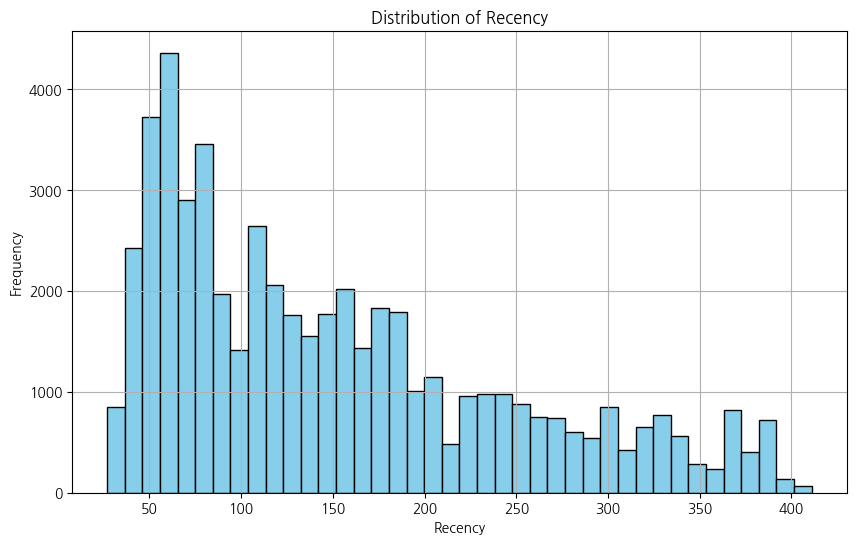

In [ ]:
# 전체 고객의 Recency 분포 시각화
plt.figure(figsize=(10, 6))
plt.hist(df['Recency'], bins=40, color='skyblue', edgecolor='black')
plt.title('Distribution of Recency')
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

> 전체 고객들의 Recency는 27에서 411까지의 범위를 갖고 있으며, 위와 같은 분포를 보인다.  
Recency를 6단계로 구분하기 위해 50일 단위로 나누기로 결정하였다.

In [ ]:
# Recency를 6단계로 구분하여 'R' 컬럼에 저장
def assign_R(recency):
    if recency <= 50:
        return 5
    elif recency <= 100:
        return 4
    elif recency <= 150:
        return 3
    elif recency <= 200:
        return 2
    elif recency <= 300:
        return 1
    else:
        return 0

df['R'] = df['Recency'].apply(assign_R)

> 1~6의 값을 갖는 'R' 컬럼을 생성하여 각 고객별 Recency 등급을 저장하였다.

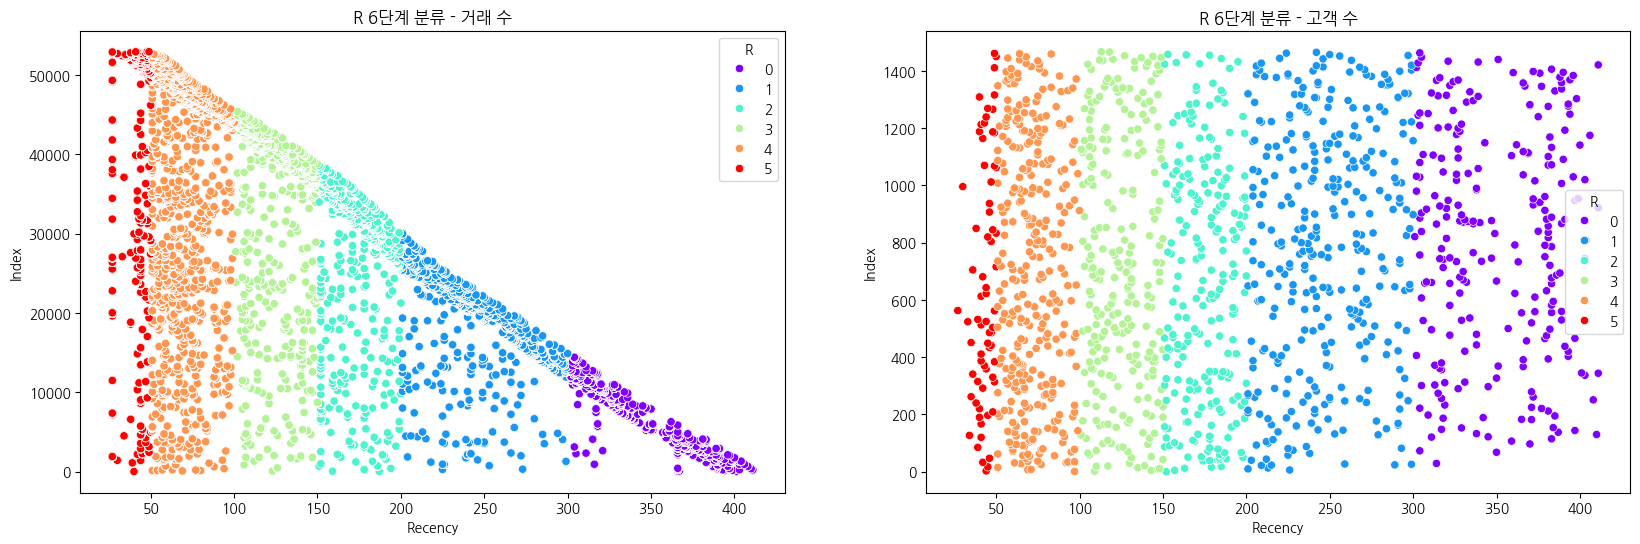

In [ ]:
# 거래행별, 고객별 R 단계 분포 시각화
f, ax = plt.subplots(1, 2, figsize=(20, 6))

sns.scatterplot(data=df, y=df.index, x='Recency', hue='R', ax=ax[0], palette='rainbow', legend='full')
ax[0].set_title('R 6단계 분류 - 거래 수')
ax[0].set_ylabel('Index')
ax[0].set_xlabel('Recency')

df_grouped = df.groupby('고객ID')[['Recency', 'R']].first().reset_index()
sns.scatterplot(data=df_grouped, y=df_grouped.index, x='Recency', hue='R', ax=ax[1], palette='rainbow', legend='full')
ax[1].set_title('R 6단계 분류 - 고객 수')
ax[1].set_ylabel('Index')
ax[1].set_xlabel('Recency')
plt.show()

In [ ]:
# R 등급별 고객 수 확인
df.groupby('R')['고객ID'].nunique()

,고객ID
R,
0,240
1,337
2,235
3,258
4,329
5,69


In [ ]:
# 가중치 제거
# 각 제품 카테고리에 해당하는 거래 날짜에 값을 빼기
for category, value in product_category_values.items():
    df.loc[df['제품카테고리'] == category, '거래날짜'] -= pd.Timedelta(days=value)

##### 2) Frequency

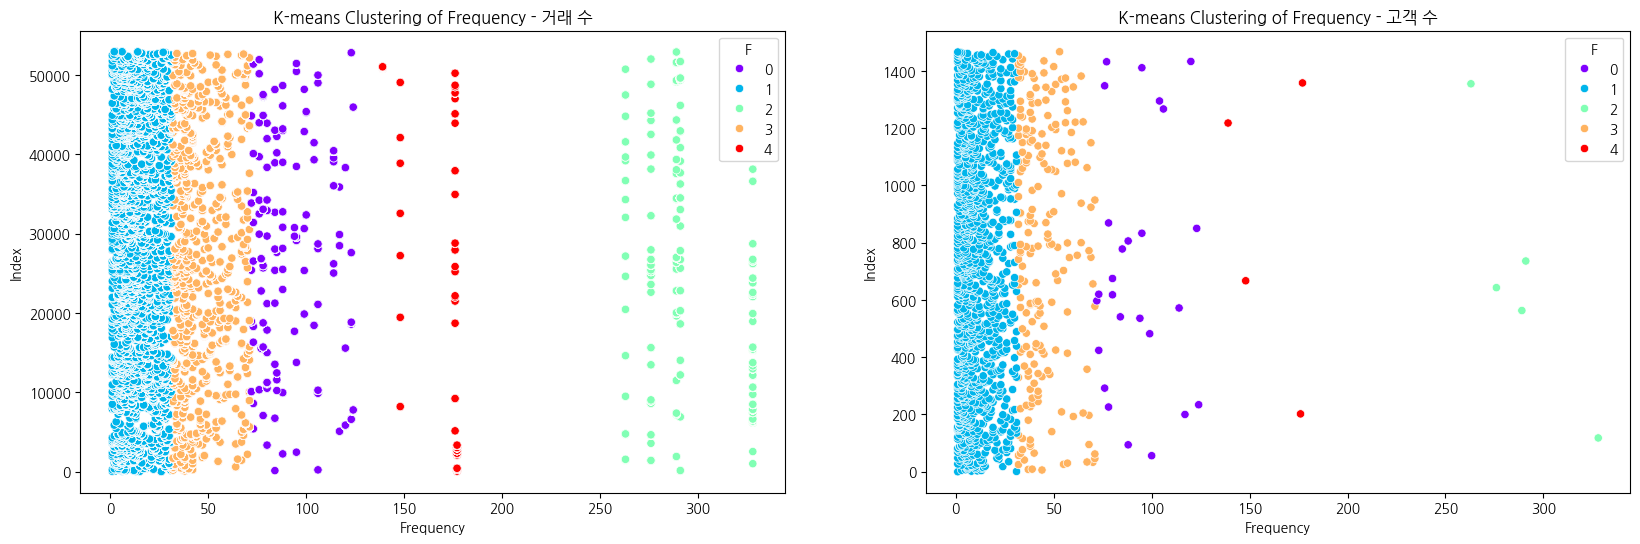

In [ ]:
from sklearn.cluster import KMeans

frequency_data = df['Frequency'].values.reshape(-1, 1)

# K-means 알고리즘을 사용하여 클러스터링 수행
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(frequency_data)

df['F'] = kmeans.labels_

f, ax = plt.subplots(1, 2, figsize=(20, 6))

# 클러스터별 거래 수 시각화
sns.scatterplot(data=df, y=df.index, x='Frequency', hue='F', ax=ax[0], palette='rainbow', legend='full')
ax[0].set_title('K-means Clustering of Frequency - 거래 수')
ax[0].set_ylabel('Index')
ax[0].set_xlabel('Frequency')

# 클러스터별 고객 수 시각화
df_grouped = df.groupby('고객ID')[['Frequency', 'F']].first().reset_index()
sns.scatterplot(data=df_grouped, y=df_grouped.index, x='Frequency', hue='F', ax=ax[1], palette='rainbow', legend='full')
ax[1].set_title('K-means Clustering of Frequency - 고객 수')
ax[1].set_ylabel('Index')
ax[1].set_xlabel('Frequency')
plt.show()

> 클러스터링만 할 경우 거래 수, 고객 수 모든 측면에서 **하위집단(클러스터 0)에 너무 편향**되어있는 문제가 발생한다.  
=> 클러스터 0(빨강색)을 모두 하위 세그먼트로 분류할 경우, 우리의 주 타겟이 될 고객층이 너무 적어진다.

In [ ]:
# 클러스터별로 1~5단계를 매핑하여 F 컬럼에 저장
label_map = {0: 3, 1: 1, 2: 5, 3:2, 4:4}
df['F'] = df['F'].map(label_map)

> 너무나도 밀집된 하위 집단을 쪼개기 위해, 하위 집단의 Frequency 25%값보다 적은 값을 갖는 **'최하위집단'**을 만든 후 F에 0값을 부여하였다.

In [ ]:
# F가 1단계인 집단의 25% 값 확인
df[df['F'] == 1].describe()

,거래날짜,수량,평균금액,배송료,월,가입기간,할인율,GST,전체금액,지불금액,Recency,Frequency,Monetary,R,F
count,26240,26240.000000,26240.0000,26240.000000,26240.000000,26240.000000,26240.000000,26240.000000,26240.000000,26240.000000,26240.000000,26240.000000,26240.000000,26240.000000,26240.0
mean,2019-07-07 18:01:12.439024128,4.496913,50.5426,10.466870,6.716540,26.291197,20.088034,0.138269,85.529574,88.733100,176.676905,16.718178,3215.152037,2.284108,1.0
min,2019-01-01 00:00:00,1.000000,0.3900,0.000000,1.000000,2.000000,0.000000,0.050000,0.400000,0.315700,34.000000,1.000000,6.990000,0.000000,1.0
25%,2019-04-12 00:00:00,1.000000,5.1000,6.000000,4.000000,15.000000,10.000000,0.100000,11.200000,12.390000,93.000000,10.000000,1598.358540,1.000000,1.0
50%,2019-07-16 00:00:00,1.000000,16.5000,6.000000,7.000000,27.000000,20.000000,0.180000,28.000000,30.420400,163.000000,17.000000,2888.382610,2.000000,1.0
75%,2019-09-28 00:00:00,2.000000,99.9900,6.500000,9.000000,38.000000,30.000000,0.180000,119.000000,130.900000,246.000000,24.000000,4290.887560,4.000000,1.0
max,2019-12-31 00:00:00,825.000000,355.7400,504.000000,12.000000,50.000000,30.000000,0.180000,6594.000000,7253.400000,411.000000,31.000000,23313.346320,5.000000,1.0
std,NaN,19.700122,62.9717,19.282939,3.334552,13.821321,8.358777,0.045526,147.731350,155.272511,96.946492,8.349311,2483.631068,1.499456,0.0


In [ ]:
# 빈도수가 8번이하인 하위 25%한테는 0점을 부여
df.loc[df['Frequency'] <= 10, 'F']=0

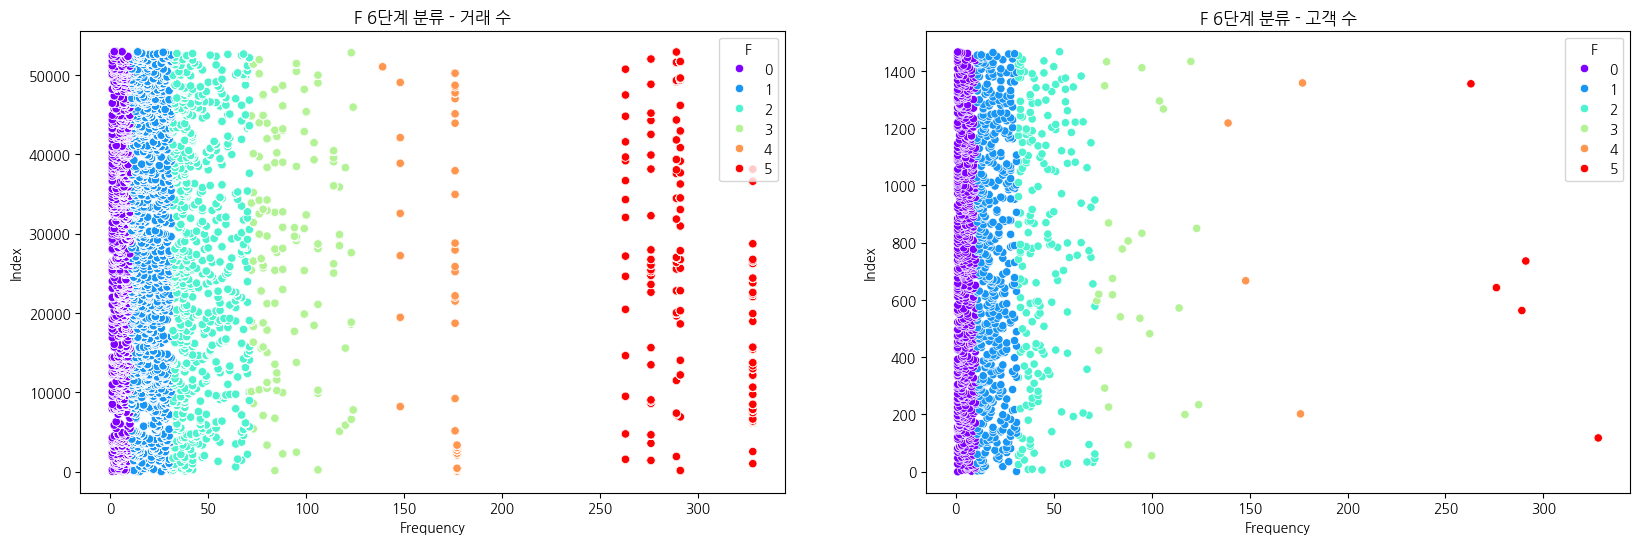

In [ ]:
# 거래행별, 고객별 최종 F 단계 분포 시각화
f, ax = plt.subplots(1, 2, figsize=(20, 6))

sns.scatterplot(data=df, y=df.index, x='Frequency', hue='F', ax=ax[0], palette='rainbow', legend='full')
ax[0].set_title('F 6단계 분류 - 거래 수')
ax[0].set_ylabel('Index')
ax[0].set_xlabel('Frequency')

df_grouped = df.groupby('고객ID')[['Frequency', 'F']].first().reset_index()
sns.scatterplot(data=df_grouped, y=df_grouped.index, x='Frequency', hue='F', ax=ax[1], palette='rainbow', legend='full')
ax[1].set_title('F 6단계 분류 - 고객 수')
ax[1].set_ylabel('Index')
ax[1].set_xlabel('Frequency')
plt.show()

In [ ]:
# F 등급별 고객 수 확인
df.groupby('F')['고객ID'].nunique()

,고객ID
F,
0,722
1,509
2,202
3,26
4,4
5,5


##### 3) Monetary

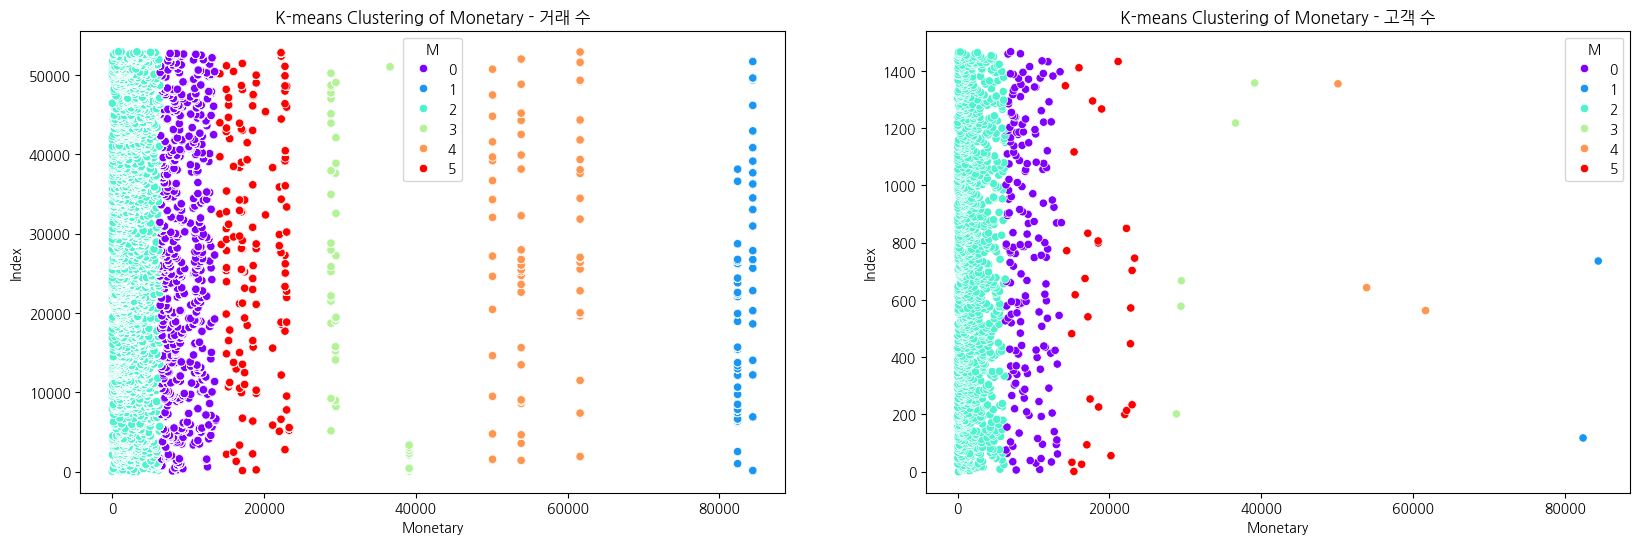

In [ ]:
monetary_data = df['Monetary'].values.reshape(-1, 1)

# K-means 알고리즘을 사용하여 클러스터링 수행
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(monetary_data)

df['M'] = kmeans.labels_

f, ax = plt.subplots(1, 2, figsize=(20, 6))

# 클러스터별 거래 수 시각화
sns.scatterplot(data=df, y=df.index, x='Monetary', hue='M', ax=ax[0], palette='rainbow', legend='full')
ax[0].set_title('K-means Clustering of Monetary - 거래 수')
ax[0].set_ylabel('Index')
ax[0].set_xlabel('Monetary')

# 클러스터별 고객 수 시각화
df_grouped = df.groupby('고객ID')[['Monetary', 'M']].first().reset_index()
sns.scatterplot(data=df_grouped, y=df_grouped.index, x='Monetary', hue='M', ax=ax[1], palette='rainbow', legend='full')
ax[1].set_title('K-means Clustering of Monetary - 고객 수')
ax[1].set_ylabel('Index')
ax[1].set_xlabel('Monetary')
plt.show()

> Frequency와 마찬가지로, 클러스터링만 할 경우 하위 집단(클러스터 0)에 대부분 편향되어있는 문제가 발생한다.

In [ ]:
# 클러스터별로 1~5단계를 매핑하여 M 컬럼에 저장
label_map = {0: 2, 1: 5, 2: 1, 3:4, 4:5, 5:3}
df['M'] = df['M'].map(label_map)

> Monetary도 동일한 과정을 거쳐 M이 1단계인 집단의 Monetary 25%값보다 적은 값을 갖는 **'최하위집단'**을 만든 후 M에 0값을 부여하였다.

In [ ]:
# M이 1단계인 집단의 Monetary 25%값 확인
df[df['M']==1].describe()

,거래날짜,수량,평균금액,배송료,월,가입기간,할인율,GST,전체금액,지불금액,Recency,Frequency,Monetary,R,F,M
count,27722,27722.000000,27722.000000,27722.000000,27722.000000,27722.000000,27722.000000,27722.000000,27722.000000,27722.000000,27722.000000,27722.000000,27722.000000,27722.000000,27722.000000,27722.0
mean,2019-07-07 05:14:12.665753088,3.997114,50.063458,10.299617,6.703340,25.777974,20.282808,0.138556,79.190099,81.812872,175.455234,18.417178,3080.167010,2.291610,0.857730,1.0
min,2019-01-01 00:00:00,1.000000,0.390000,0.000000,1.000000,2.000000,0.000000,0.050000,0.400000,0.315700,34.000000,1.000000,6.990000,0.000000,0.000000,1.0
25%,2019-04-13 00:00:00,1.000000,5.100000,6.000000,4.000000,14.000000,10.000000,0.100000,11.190000,12.260200,96.000000,10.000000,1677.026800,1.000000,0.000000,1.0
50%,2019-07-16 00:00:00,1.000000,16.300000,6.000000,7.000000,25.000000,20.000000,0.180000,27.180000,28.858080,159.000000,17.000000,3037.746320,2.000000,1.000000,1.0
75%,2019-09-26 00:00:00,2.000000,99.000000,6.500000,9.000000,38.000000,30.000000,0.180000,119.000000,130.900000,242.000000,26.000000,4498.714360,4.000000,1.000000,1.0
max,2019-12-31 00:00:00,825.000000,355.740000,504.000000,12.000000,50.000000,30.000000,0.180000,1995.000000,1764.100000,411.000000,49.000000,6260.270280,5.000000,2.000000,1.0
std,NaN,16.133741,62.326850,18.437427,3.311581,13.936540,8.356921,0.045444,109.530114,113.288049,95.740344,10.144656,1691.181791,1.479544,0.607093,0.0


In [ ]:
# M이 1단계인 고객들 내에서 그들의 Monetary 25% 값 이하인 고객들을 0단계로 다시 분류
df.loc[df['Monetary'] <= 1677.026800, 'M'] = 0

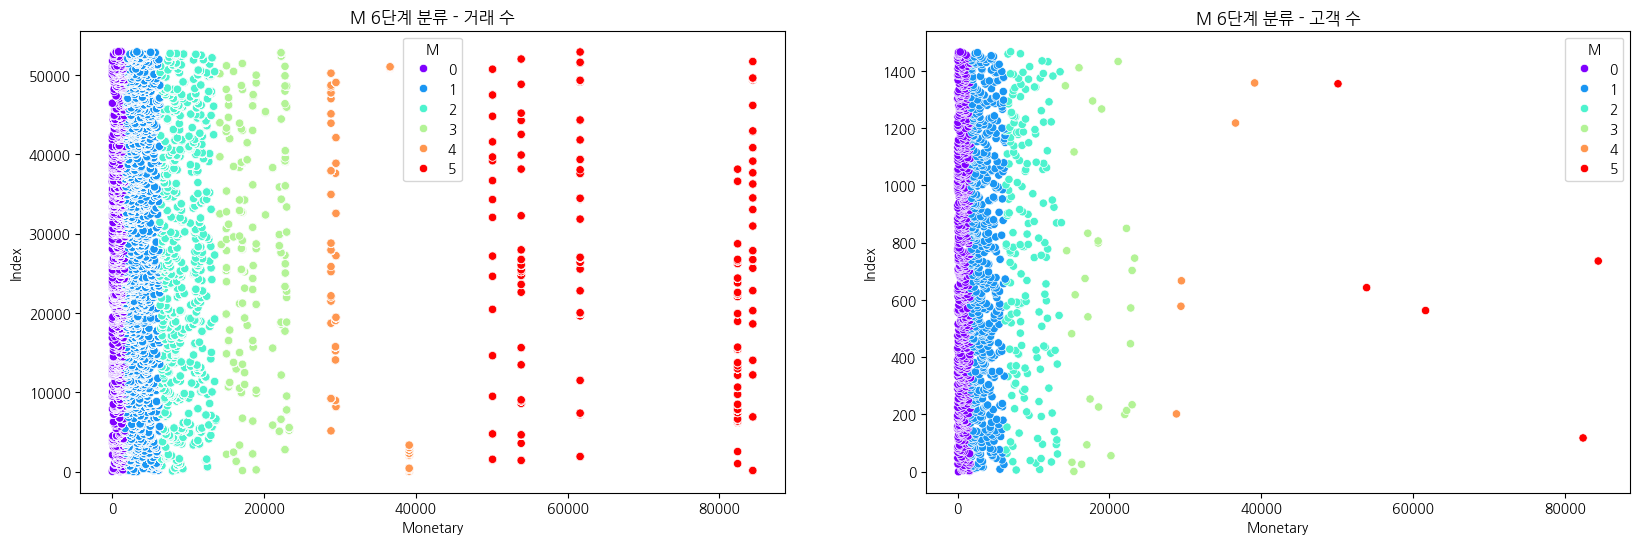

In [ ]:
# 거래행별, 고객별 최종 M 분포 시각화
f, ax = plt.subplots(1, 2, figsize=(20, 6))

sns.scatterplot(data=df, y=df.index, x='Monetary', hue='M', ax=ax[0], palette='rainbow', legend='full')
ax[0].set_title('M 6단계 분류 - 거래 수')
ax[0].set_ylabel('Index')
ax[0].set_xlabel('Monetary')

df_grouped = df.groupby('고객ID')[['Monetary', 'M']].first().reset_index()
sns.scatterplot(data=df_grouped, y=df_grouped.index, x='Monetary', hue='M', ax=ax[1], palette='rainbow', legend='full')
ax[1].set_title('M 6단계 분류 - 고객 수')
ax[1].set_ylabel('Index')
ax[1].set_xlabel('Monetary')
plt.show()

In [ ]:
# M 등급별 고객 수 확인
df.groupby('M')['고객ID'].nunique()

,고객ID
M,
0,674
1,571
2,184
3,29
4,5
5,5


#### (3) 고객 세그먼트 분류

In [ ]:
def classify_customer_segment(row):
    R, F, M = row['R'], row['F'], row['M']

    if R == 5 and F == 5 and M == 5:
        return 'VIP고객'
    elif R >= 3 and F >= 3 and M >= 3:
        return '충성고객'
    elif R >= 2 and F >= 2 and M >= 1:
        return '잠재충성고객'
    elif R >= 0 and F >= 2 and M >= 2:
        return '놓치면안될고객'
    elif R >= 3 and F >= 0 and M >= 0:
        return '최근신규방문고객'
    elif R >= 0 and F >= 1 and M >= 1:
        return '이탈우려고객'
    else:
        return '기타'

# df에 'segment' 컬럼 추가
df['segment'] = df.apply(classify_customer_segment, axis=1)

* **VIP고객**: 최근 구매, 자주 큰 금액을 소비한 그룹
* **충성고객**: 최근 구매, 자주 많은 금액을 소비했으나 VIP 고객보다는 매출기여도가 낮은 그룹
* **잠재충성고객**: 최근에 구매한 편, 적당히 자주 구매, 소비한 금액은 많지 않은 편인 그룹
* **최근신규방문고객**: 최근에 구매했으나 자주 방문하지는 않은 그룹
* **놓치면안될고객**: 과거에 자주 구매하고 많은 금액을 소비했으나 오랫동안 방문하지 않은 그룹
* **이탈우려고객**: 과거에 적당히 자주 구매하고 평균 정도의 금액을 소비하였으나 오랫동안 방문하지 않은 그룹

In [ ]:
df.groupby(['segment'])['고객ID'].nunique()

,고객ID
segment,
VIP고객,2
기타,511
놓치면안될고객,37
이탈우려고객,235
잠재충성고객,165
최근신규방문고객,496
충성고객,22


### 1-3. 추가 변수 생성

#### (1) 최초거래월

> 최초거래월: 2019년에 고객이 처음 거래한 달

In [ ]:
grouping = df.groupby('고객ID')['월']
df['최초거래월'] = grouping.transform('min')

#### (2) 경과월

> 경과월: 첫 거래월로부터 경과한 개월수

In [ ]:
# 열이름 변경
df = df.rename(columns={'월': '거래월'})

In [ ]:
# 경과월 컬럼 생성
df['경과월'] = df['거래월'] - df['최초거래월']

#### (3) 가입년월

> 가입년월: 2020년 1월 1일 기준으로 가입기간을 계산하여 얻은 날짜

##### 1) 가입년월을 거래 날짜 기준으로 계산해보기

In [ ]:
# 가입월 변수 생성 (임시값 '데이콘' 부여 후 반복문으로 계산)
df['가입년월'] = '데이콘'

for k in range(len(df)):
  df['가입년월'][k] = pd.to_datetime(df['거래날짜'][k]) - pd.DateOffset(months=df['가입기간'][k])

In [ ]:
# 임의의 고객으로 가입년월이 옳게 되었는지 확인하기
df[df['고객ID'] == "USER_0118"]

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,거래월,성별,고객지역,가입기간,쿠폰코드,할인율,GST,전체금액,지불금액,Recency,Frequency,Monetary,R,F,M,segment,최초거래월,경과월,가입년월
1015,USER_0118,Transaction_0536,2019-01-08,Product_0201,Apparel,3,14.02,62.74,Used,1,여,Chicago,28,SALE10,10.0,0.18,42.06,44.66772,152,328,82405.31626,2,5,5,잠재충성고객,1,0,2016-09-08 00:00:00
2541,USER_0118,Transaction_1339,2019-01-20,Product_0981,Nest-USA,1,153.71,6.50,Used,1,여,Chicago,28,ELEC10,10.0,0.10,153.71,152.17290,152,328,82405.31626,2,5,5,잠재충성고객,1,0,2016-09-20 00:00:00
6158,USER_0118,Transaction_3192,2019-02-18,Product_0976,Nest-USA,2,119.00,6.50,Clicked,2,여,Chicago,28,ELEC20,20.0,0.10,238.00,261.80000,152,328,82405.31626,2,5,5,잠재충성고객,1,1,2016-10-18 00:00:00
6159,USER_0118,Transaction_3193,2019-02-18,Product_0976,Nest-USA,2,119.00,6.50,Used,2,여,Chicago,28,ELEC20,20.0,0.10,238.00,209.44000,152,328,82405.31626,2,5,5,잠재충성고객,1,1,2016-10-18 00:00:00
6160,USER_0118,Transaction_3194,2019-02-18,Product_0976,Nest-USA,1,119.00,6.50,Clicked,2,여,Chicago,28,ELEC20,20.0,0.10,119.00,130.90000,152,328,82405.31626,2,5,5,잠재충성고객,1,1,2016-10-18 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36597,USER_0118,Transaction_16284,2019-09-05,Product_0984,Nest-USA,1,79.00,6.00,Used,9,여,Chicago,28,ELEC30,30.0,0.10,79.00,60.83000,152,328,82405.31626,2,5,5,잠재충성고객,1,8,2017-05-05 00:00:00
38121,USER_0118,Transaction_16900,2019-09-15,Product_0117,Apparel,1,39.19,75.00,Used,9,여,Chicago,28,SALE30,30.0,0.18,39.19,32.37094,152,328,82405.31626,2,5,5,잠재충성고객,1,8,2017-05-15 00:00:00
38122,USER_0118,Transaction_16900,2019-09-15,Product_0286,Apparel,1,16.99,75.00,Used,9,여,Chicago,28,SALE30,30.0,0.18,16.99,14.03374,152,328,82405.31626,2,5,5,잠재충성고객,1,8,2017-05-15 00:00:00
38123,USER_0118,Transaction_16900,2019-09-15,Product_0942,Office,1,2.50,75.00,Clicked,9,여,Chicago,28,OFF30,30.0,0.10,2.50,2.75000,152,328,82405.31626,2,5,5,잠재충성고객,1,8,2017-05-15 00:00:00


> 같은 고객이지만, 거래날짜를 기준으로 가입년월을 계산하니 가입년월이 일정하지 않다는 문제점이 발견되었다. 즉, 가입기간이 **특정 시점을 기준**으로 한다는 점을 알 수 있다.

In [ ]:
# 거래날짜 기간 확인
df['거래날짜'].min(), df['거래날짜'].max()

(Timestamp('2019-01-01 00:00:00'), Timestamp('2019-12-31 00:00:00'))

> 데이터가 2019년 12월 31일까지 존재하기 때문에, 특정 시점을 ***2020년 1월 1일***로 지정하여 가입기간을 재계산하였다.

##### 2) 2020-01-01 기준으로 재계산

In [ ]:
# 2020-01-01 시점 기준 가입년월 재계산
for k in range(len(df)):
  df['가입년월'][k] = pd.to_datetime("2020-01-01") - pd.DateOffset(months = df['가입기간'][k])

In [ ]:
# 가입년월이 고정되었는지 확인
df[df['고객ID'] == "USER_0118"]

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,거래월,성별,고객지역,가입기간,쿠폰코드,할인율,GST,전체금액,지불금액,Recency,Frequency,Monetary,R,F,M,segment,최초거래월,경과월,가입년월
1015,USER_0118,Transaction_0536,2019-01-08,Product_0201,Apparel,3,14.02,62.74,Used,1,여,Chicago,28,SALE10,10.0,0.18,42.06,44.66772,152,328,82405.31626,2,5,5,잠재충성고객,1,0,2017-09-01 00:00:00
2541,USER_0118,Transaction_1339,2019-01-20,Product_0981,Nest-USA,1,153.71,6.50,Used,1,여,Chicago,28,ELEC10,10.0,0.10,153.71,152.17290,152,328,82405.31626,2,5,5,잠재충성고객,1,0,2017-09-01 00:00:00
6158,USER_0118,Transaction_3192,2019-02-18,Product_0976,Nest-USA,2,119.00,6.50,Clicked,2,여,Chicago,28,ELEC20,20.0,0.10,238.00,261.80000,152,328,82405.31626,2,5,5,잠재충성고객,1,1,2017-09-01 00:00:00
6159,USER_0118,Transaction_3193,2019-02-18,Product_0976,Nest-USA,2,119.00,6.50,Used,2,여,Chicago,28,ELEC20,20.0,0.10,238.00,209.44000,152,328,82405.31626,2,5,5,잠재충성고객,1,1,2017-09-01 00:00:00
6160,USER_0118,Transaction_3194,2019-02-18,Product_0976,Nest-USA,1,119.00,6.50,Clicked,2,여,Chicago,28,ELEC20,20.0,0.10,119.00,130.90000,152,328,82405.31626,2,5,5,잠재충성고객,1,1,2017-09-01 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36597,USER_0118,Transaction_16284,2019-09-05,Product_0984,Nest-USA,1,79.00,6.00,Used,9,여,Chicago,28,ELEC30,30.0,0.10,79.00,60.83000,152,328,82405.31626,2,5,5,잠재충성고객,1,8,2017-09-01 00:00:00
38121,USER_0118,Transaction_16900,2019-09-15,Product_0117,Apparel,1,39.19,75.00,Used,9,여,Chicago,28,SALE30,30.0,0.18,39.19,32.37094,152,328,82405.31626,2,5,5,잠재충성고객,1,8,2017-09-01 00:00:00
38122,USER_0118,Transaction_16900,2019-09-15,Product_0286,Apparel,1,16.99,75.00,Used,9,여,Chicago,28,SALE30,30.0,0.18,16.99,14.03374,152,328,82405.31626,2,5,5,잠재충성고객,1,8,2017-09-01 00:00:00
38123,USER_0118,Transaction_16900,2019-09-15,Product_0942,Office,1,2.50,75.00,Clicked,9,여,Chicago,28,OFF30,30.0,0.10,2.50,2.75000,152,328,82405.31626,2,5,5,잠재충성고객,1,8,2017-09-01 00:00:00


#### (4) 가입기간2

> 가입기간에 따른 차이를 확인해보기 위하여, 가입기간을 크게 아래 세 가지 분류로 나눈 컬럼 '가입기간2'를 생성하였다.

> <가입기간2 분류>
* long: 가입기간 3년 이상
* medium: 가입기간 1~2년
* short: 가입기간 1년 미만

In [ ]:
df['가입기간2'] = "unknown"

for i in range(len(df)):
  if df['가입기간'][i] >= 36:
    df['가입기간2'][i] = 'long'
  elif df['가입기간'][i] >= 12:
    df['가입기간2'][i] = 'medium'
  else:
    df['가입기간2'][i] = 'short'

#### (5) 고객유형

> 고객유형
* 2019년 가입자: 신규고객
* 2019년 이전 가입자: 기존고객

In [ ]:
# 고객유형 컬럼 생성
df['가입년월'] = pd.to_datetime(df['가입년월'])
df['거래날짜'] = pd.to_datetime(df['거래날짜'])

df.loc[df['가입년월'].dt.year == 2019, '고객유형'] = '신규고객'
df.loc[df['가입년월'].dt.year != 2019, '고객유형'] = '기존고객'

### 1-4. 코호트 함수 생성 및 분석

##### (1) 코호트 함수 생성

In [ ]:
# 여러 개 코호트 출력시 사용
def cohort(a, b, c, d, list1, list2, max):
  fig, axs = plt.subplots(a, b, figsize=(c, d))
  for i in range(len(list1)):
    grouping = list2[i].groupby(['최초거래월', '경과월'])
    cohort_data = grouping['고객ID'].apply(pd.Series.nunique)
    cohort_data = cohort_data.reset_index()
    cohort_counts = cohort_data.pivot(index='최초거래월',columns='경과월',values='고객ID')
    cohort_size = cohort_counts.iloc[:,0]
    retention = cohort_counts.divide(cohort_size,axis=0)

    axs[i].set_title(list1[i])
    ax = sns.heatmap(data=retention, annot=True, fmt='.0%', vmin=0.0, vmax=max, cmap="Blues", ax=axs[i])
    ax.set_yticklabels([f'{int(label.get_text())}월' for label in ax.get_yticklabels()], rotation=0)
    ax.set_xlabel('경과월(개월 후)')
    ax.set_ylabel('2019년 최초거래월')
  plt.tight_layout()
  plt.show()

In [ ]:
# 하나 코호트 출력시 사용
def cohort_one(title, DF, max):
  grouping = DF.groupby(['최초거래월', '경과월'])
  cohort_data = grouping['고객ID'].apply(pd.Series.nunique)
  cohort_data = cohort_data.reset_index()
  cohort_counts = cohort_data.pivot(index='최초거래월',columns='경과월',values='고객ID')
  cohort_size = cohort_counts.iloc[:,0]
  retention = cohort_counts.divide(cohort_size,axis=0)

  plt.figure(figsize=(9, 6))
  plt.title(title)
  ax = sns.heatmap(data=retention, annot=True, fmt='.0%', vmin=0.0, vmax=max, cmap='Blues')
  ax.set_yticklabels([f'{int(label.get_text())}월' for label in ax.get_yticklabels()], rotation=0)
  ax.set_xlabel('경과월(개월 후)')
  ax.set_ylabel('2019년 최초거래월')
  plt.show()

##### (2) 전체 리텐션 vs. 타겟 리텐션

> 앞서 RFM 고객 세그먼트 분류를 통하여 '기타'를 제외한 세그먼트들을 주마케팅 대상으로 선정하였다. 이에 기타를 제외한 세그먼트들을 '타겟'으로 삼아 전체 고객 대비 타겟 고객들의 리텐션이 어떻게 차이가 나는지 코호트를 통해 살펴보았다.
* 타겟: 세그먼트에서 기타를 제외한 고객군

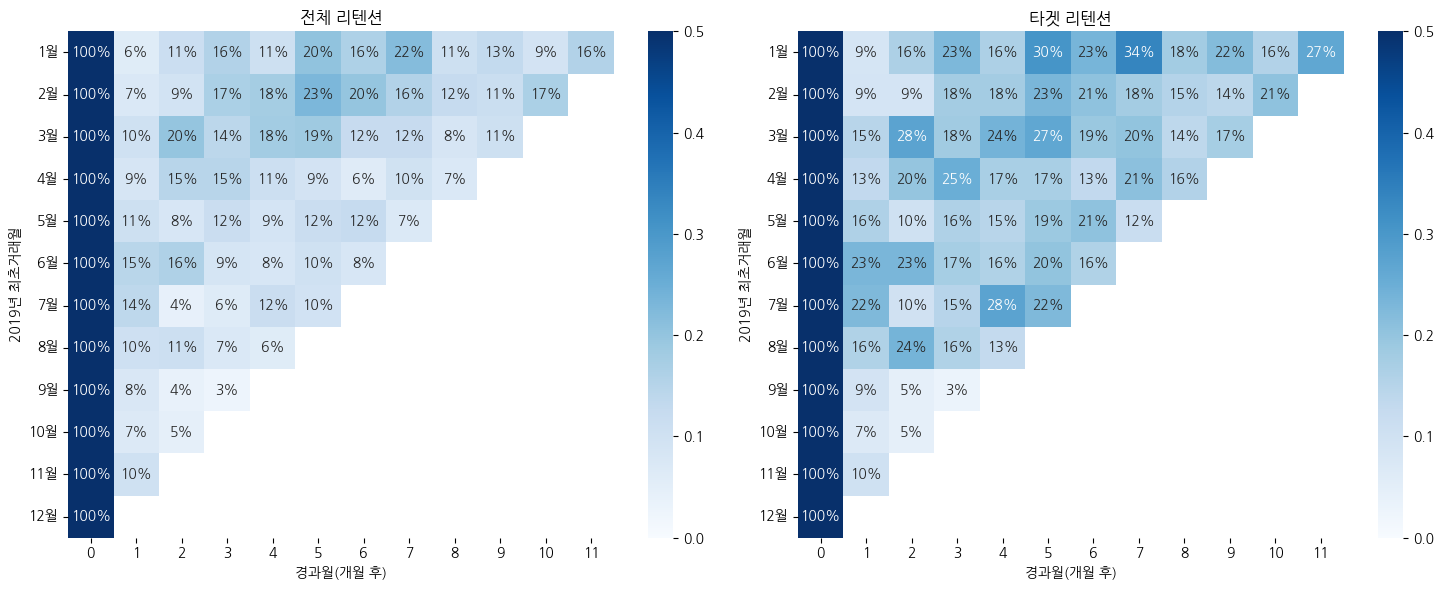

In [ ]:
df1 = df[~df['segment'].isin(["기타"])]
list1 = ['전체 리텐션', '타겟 리텐션']
list2 = [df, df1]
cohort(1, 2, 15, 6, list1, list2, 0.5)

> 타겟의 리텐션이 전체 고객의 리텐션보다 높음을 알 수 있다.

#### (3) 가입기간별 코호트 분석

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. '가입기간' 데이터 복구하기 (df의 가입기간이 깨졌을 수 있으므로 customer에서 다시 가져옴)
try:
    # 고객ID를 기준으로 가입기간을 다시 매핑
    df['가입기간'] = df['고객ID'].map(customer.set_index('고객ID')['가입기간'])
except NameError:
    print("ustomer 변수가 없습니다.")

# 2. '가입기간'을 숫자로 변환
df['가입기간'] = pd.to_numeric(df['가입기간'], errors='coerce').fillna(0).astype(int)

# 3. '가입기간2' 다시 분류 (apply 함수 사용)
def classify_period(months):
    if months >= 36:
        return 'long'
    elif months >= 12:
        return 'medium'
    else:
        return 'short'

df['가입기간2'] = df['가입기간'].apply(classify_period)

# 4. 데이터 분포 재확인
print("\n--- [데이터 분포 확인] ---")
print(df['가입기간2'].value_counts())
print("-" * 30)

# 5. 데이터셋 나누기
long = df[df['가입기간2'] == "long"]
medium = df[df['가입기간2'] == "medium"]
short = df[df['가입기간2'] == "short"]

# 6. 코호트 분석 함수 실행
if len(short) > 0 and len(medium) > 0 and len(long) > 0:
    list1 = ['1년 미만 고객(Short)', '1~2년 고객(Medium)', '3년 이상 고객(Long)']
    list2 = [short, medium, long]


--- [데이터 분포 확인] ---
가입기간2
medium    27388
long      15205
short     10331
Name: count, dtype: int64
------------------------------


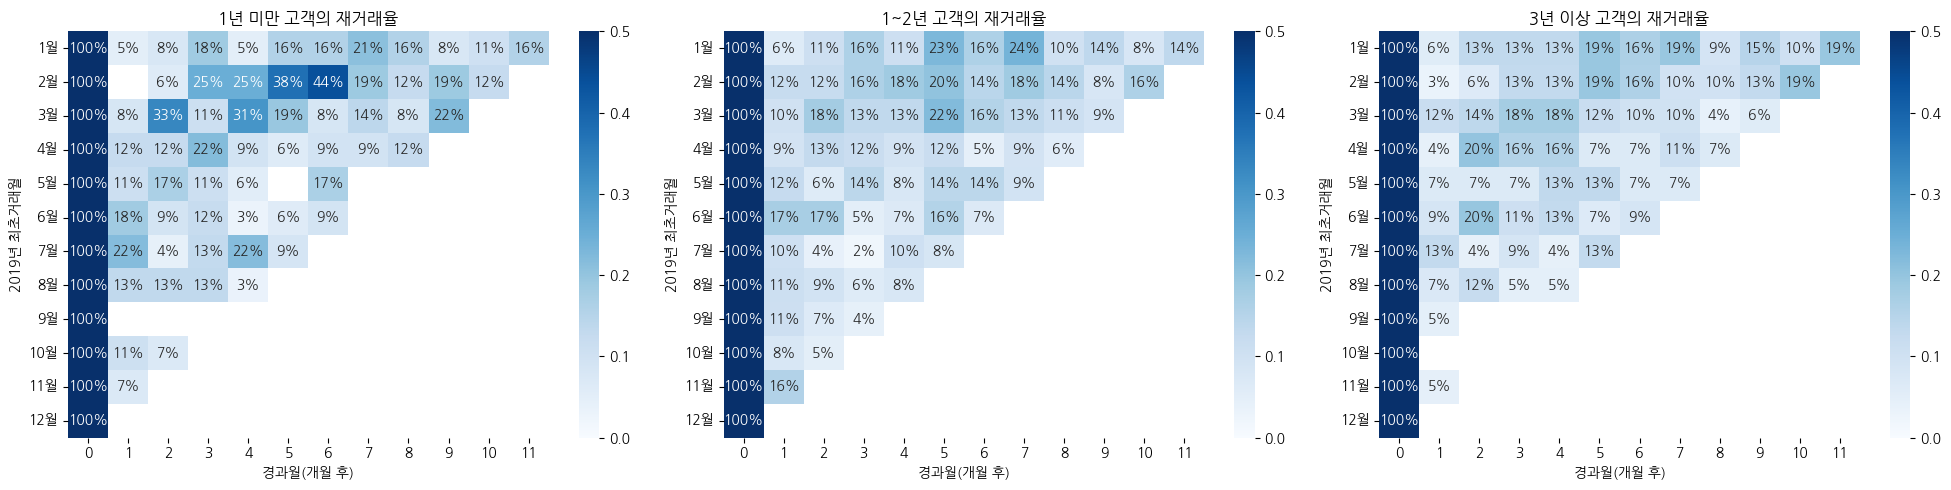

In [ ]:
long = df[df['가입기간2'] == "long"]
medium = df[df['가입기간2'] == "medium"]
short = df[df['가입기간2'] == "short"]

list1 = ['1년 미만 고객의 재거래율', '1~2년 고객의 재거래율', '3년 이상 고객의 재거래율']
list2 = [short, medium, long]

cohort(1,3, 20, 5, list1, list2, 0.5)

> 가입기간을 나누어 살펴본 결과,

    1) 신규고객의 리텐션이 다른 고객보다 높음을 알 수 있다.

    2) 전체적으로 6~8월의 리텐션이 다른 달보다 높음을 볼 수 있다.

### 1-5. 제품 카테고리별 상관관계 분석

In [ ]:
# 상관 분석에 필요한 데이터 테이블 생성
pivot_ = df.pivot_table(index='거래월', columns='제품카테고리', values='수량', aggfunc='sum')
print(pivot_)

제품카테고리  Accessories  Android  Apparel  Backpacks    Bags  Bottles  Drinkware  \
거래월                                                                            
1               1.0      4.0   1500.0        3.0   860.0    185.0     2140.0   
2               NaN      1.0   1559.0        6.0  2151.0    107.0     1866.0   
3               1.0      7.0   2303.0        7.0  1421.0    182.0     2976.0   
4               4.0      2.0   4052.0       16.0  1344.0    140.0     3022.0   
5               6.0      5.0   2829.0       24.0  1158.0    316.0     2272.0   
6               7.0     10.0   2551.0        4.0  1503.0    165.0     3353.0   
7              44.0      9.0   4307.0        8.0  1197.0    294.0     2539.0   
8              14.0      7.0   3950.0       15.0  2110.0     93.0     3900.0   
9              56.0      NaN   3731.0        7.0  1055.0    433.0     3169.0   
10            201.0      NaN   1733.0       19.0  1534.0    175.0     2997.0   
11            563.0      NaN   1247.0   

In [ ]:
# 상관분석 실행
correlation_matrix = pivot_.corr()
correlation_matrix = correlation_matrix.fillna(0)

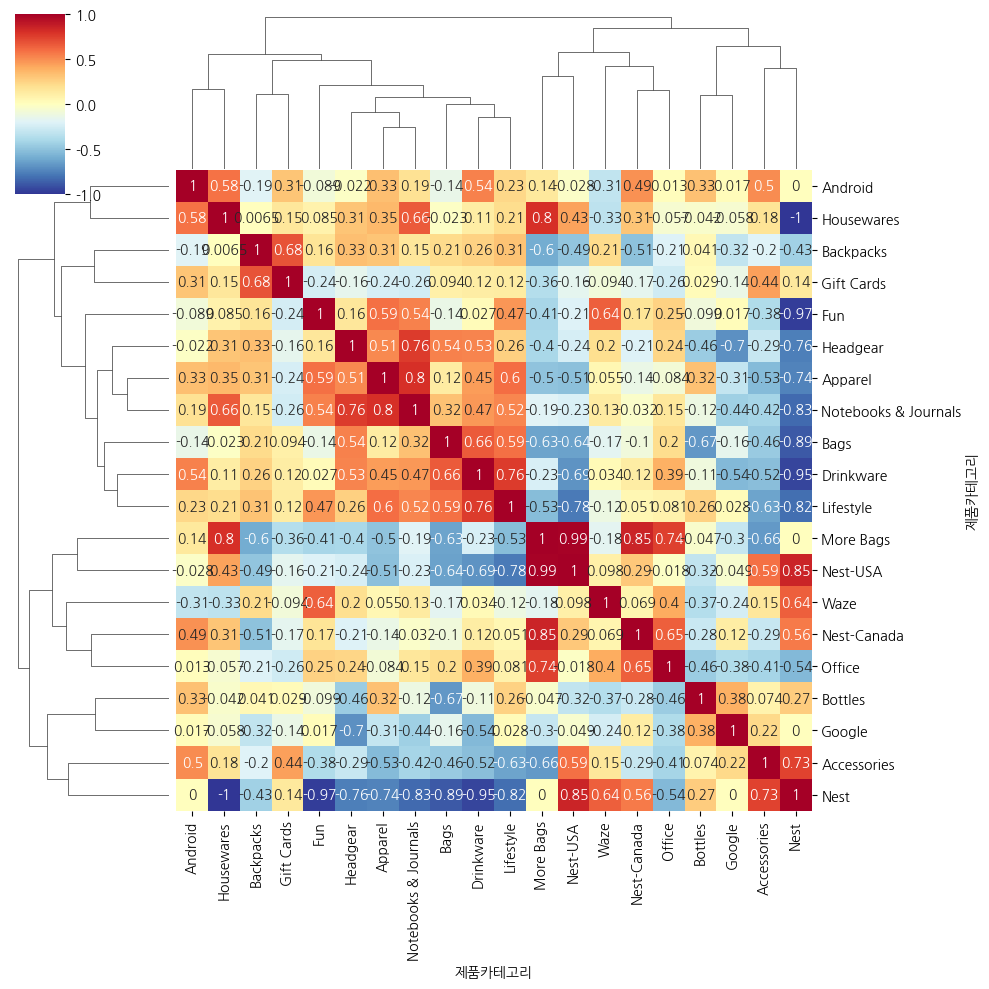

In [ ]:
# 상관분석 결과를 클러스터맵으로 출력
sns.clustermap(correlation_matrix, annot=True, cmap='RdYlBu_r',
               vmin=-1,vmax=1,)

In [ ]:
import pandas as pd

# 0.7 이상의 상관 관계 항목 선택
strong_correlation = correlation_matrix[correlation_matrix > 0.7]
strong_correlation = strong_correlation.dropna(axis=1, how='all').dropna(how='all')

# 데이터를 모을 리스트 초기화
rows_list = []

# 반복문으로 데이터 수집
for column in strong_correlation.columns:
    for index in strong_correlation.index:
        # 자기 자신과의 상관관계 제외 및 결측치 체크
        if column != index and not pd.isna(strong_correlation.loc[index, column]):
            rows_list.append({
                'Category_1': index,
                'Category_2': column,
                'Correlation': strong_correlation.loc[index, column]
            })

# 리스트를 DataFrame으로 변환
high_correlation_df = pd.DataFrame(rows_list)

# 결과 확인
print(high_correlation_df)

              Category_1            Category_2  Correlation
0                   Nest           Accessories     0.734635
1   Notebooks & Journals               Apparel     0.804184
2              Lifestyle             Drinkware     0.763320
3   Notebooks & Journals              Headgear     0.761021
4              More Bags            Housewares     0.801332
5              Drinkware             Lifestyle     0.763320
6             Housewares             More Bags     0.801332
7            Nest-Canada             More Bags     0.847532
8               Nest-USA             More Bags     0.987012
9                 Office             More Bags     0.743187
10           Accessories                  Nest     0.734635
11              Nest-USA                  Nest     0.851155
12             More Bags           Nest-Canada     0.847532
13             More Bags              Nest-USA     0.987012
14                  Nest              Nest-USA     0.851155
15               Apparel  Notebooks & Jo

거래월별 제품 카테고리 구매 수량의 상관 관계를 분석해본 결과 0.7 이상의 높은 상관 관계를 가진 제품 카테고리는 위 리스트와 같다. 가장 높은 상관관계를 가진 제품은 Nest-USA와 More Bags이다.

### 1-6. 제품 카테고리별 연관 분석

In [ ]:
#연관분석에 필요한 칼럼을 따로 df_apriori에 저장
df_apriori = df[['고객ID', '제품카테고리', '수량']]

# 분석에 맞는 형태로 데이터 리스트화 후 apriori에 저장
apriori = df_apriori.groupby('고객ID')['제품카테고리'].apply(list).values.tolist()

In [ ]:
# 리스트 내 중복되는 요소 모두 제거
unique_lists = []

for sublist in apriori:
    unique_sublist = []
    for item in sublist:
        if item not in unique_sublist:
            unique_sublist.append(item)
    unique_lists.append(unique_sublist)

# 제거 후 데이터 셋으로 이름을 변경
dataset = unique_lists

In [ ]:
# 트랜잭션 데이터를 이진 형태로 인코딩하여 희소 행렬을 생성
te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset, sparse=True)
te_df = pd.DataFrame.sparse.from_spmatrix(te_ary, columns =te.columns_)

In [ ]:
# Apriori 알고리즘 적용
from mlxtend.frequent_patterns import apriori

frequent_itemset = apriori(te_df,
                           min_support = 0.005,
                           max_len =3,
                           use_colnames = True,
                           verbose = 1
                           )
frequent_itemset['length'] = frequent_itemset['itemsets'].map(lambda x:len(x))
frequent_itemset.sort_values('support', ascending = False, inplace=True)

Processing 3174 combinations | Sampling itemset size 3


In [ ]:
# 연관 규칙 찾기
association_rules_df = association_rules(frequent_itemset,
                                          metric='confidence',
                                          min_threshold=0.005,
                                        )

In [ ]:
# 조건부, 결과부, 지지도, 신뢰도, 향상도를 따로 sep에 저장
sep = association_rules_df[['antecedents','consequents', 'support', 'confidence', 'lift']]

# 최소지지도가 0.6이며, 향상도는 1 이상
sep = sep[sep['support']> 0.6]
sep = sep[sep['lift'] > 1]

In [ ]:
# 향상도를 내림차순으로 정리
association = sep.sort_values(by='lift', ascending=False).head(5)
association

,antecedents,consequents,support,confidence,lift
10,(Office),"(Nest-USA, Apparel)",0.661444,0.880326,1.107386
7,"(Nest-USA, Apparel)",(Office),0.661444,0.832048,1.107386
8,"(Office, Apparel)",(Nest-USA),0.661444,0.928298,1.081541
9,(Nest-USA),"(Office, Apparel)",0.661444,0.770635,1.081541
6,"(Nest-USA, Office)",(Apparel),0.661444,0.965209,1.070995


In [ ]:
# top5만 출력
max_i = 4
for i, row in association.iterrows():
      print("제품: " + list(row['antecedents'])[0] + " => " + list(row['consequents'])[0])
      print("지지도: " + str(round(row['support'],2)))
      print("신뢰도: " + str(round(row['confidence'],2)))
      print("향상도: " + str(round(row['lift'],2)))
      print("=====================================")
      if i==max_i:
          break

제품: Office => Nest-USA
지지도: 0.66
신뢰도: 0.88
향상도: 1.11
제품: Nest-USA => Office
지지도: 0.66
신뢰도: 0.83
향상도: 1.11
제품: Office => Nest-USA
지지도: 0.66
신뢰도: 0.93
향상도: 1.08
제품: Nest-USA => Office
지지도: 0.66
신뢰도: 0.77
향상도: 1.08
제품: Nest-USA => Apparel
지지도: 0.66
신뢰도: 0.97
향상도: 1.07


위 리스트에서 제품 A -> B에 대한 해석으로 지지도는 두 제품을 모두 구매한 고객 수의 비율을 말하고, 신뢰도는 A를 구매한 고객 중 B를 구매한 고객의 비율을 말하고, 향상도는 마케팅 효과 증가율을 말한다.

따라서 가장 높은 연관성을 가진 제품 카테고리는 Office -> Apparel이다. 두 제품 카테고리 모두 구매한 고객 수가 전체의 66%이고, Office 제품을 구매한 고객 중 Apparel도 구매한 고객 비율은 88%이고, 함께 마케팅 할 경우 11% 효과를 볼 수 있다.

# 2️⃣ 고객 세그먼트별 분석

### 세그먼트 비율 파악

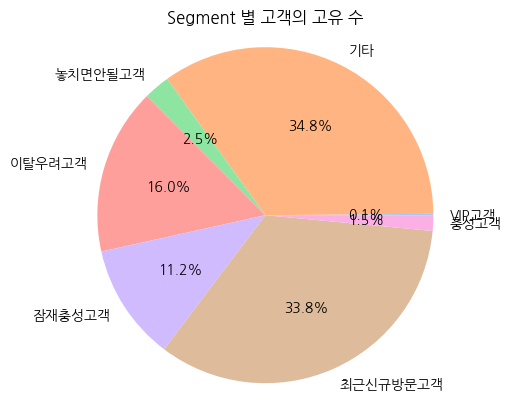

In [ ]:
color_palette = sns.color_palette('pastel')

counts = df.groupby(['segment'])['고객ID'].nunique()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=color_palette)
plt.title('Segment 별 고객의 고유 수')
plt.axis('equal')
plt.show()

### 세그먼트별 남/녀 성비 파악

In [ ]:
segments = df['segment'].unique()
data_list = [] # 1. 빈 리스트 생성

for segment in segments:
    # 기존 계산 로직 유지
    female_count = df[(df['segment'] == segment) & (df['성별'] == '여')]['성별'].count()
    male_count = df[(df['segment'] == segment) & (df['성별'] == '남')]['성별'].count()
    total_count = df[df['segment'] == segment]['성별'].count()

    # 0으로 나누기 방지 (안전 장치 추가)
    if total_count > 0:
        female_ratio = female_count / total_count
        male_ratio = male_count / total_count
    else:
        female_ratio = 0
        male_ratio = 0

    # 2. 리스트에 딕셔너리 추가 (append는 여기서 사용)
    data_list.append({
        'Segment': segment,
        '여': f"{female_ratio:.2%}",
        '남': f"{male_ratio:.2%}"
    })

# 3. 리스트를 한 번에 데이터프레임으로 변환
ratio_df = pd.DataFrame(data_list)

# 결과 확인
print(ratio_df)

    Segment        여       남
0   놓치면안될고객   51.37%  48.63%
1  최근신규방문고객   60.06%  39.94%
2    이탈우려고객   64.62%  35.38%
3        기타   60.44%  39.56%
4    잠재충성고객   69.30%  30.70%
5      충성고객   44.87%  55.13%
6     VIP고객  100.00%   0.00%


### 2-1.VIP고객

* VIP고객의 고객 수는 2명, 전체 고객의 0.1%

In [ ]:
vip = df[df['segment']=='VIP고객']

In [ ]:
vip.groupby('고객ID')[['Recency', 'Frequency', 'Monetary']].first()

,Recency,Frequency,Monetary
고객ID,,,
USER_0563,27,289,61651.32347
USER_0643,44,276,53883.15771


In [ ]:
# vip 고객 2명의 월별 구매 빈도 파악
vip_month = vip.pivot_table(index='고객ID', columns='거래월', aggfunc='size', fill_value=0).reset_index()
vip_month.columns.name=None
vip_month = vip_month[['고객ID', 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]]

vip_month_melt = vip_month.melt(id_vars='고객ID', var_name='거래월', value_name='counts')

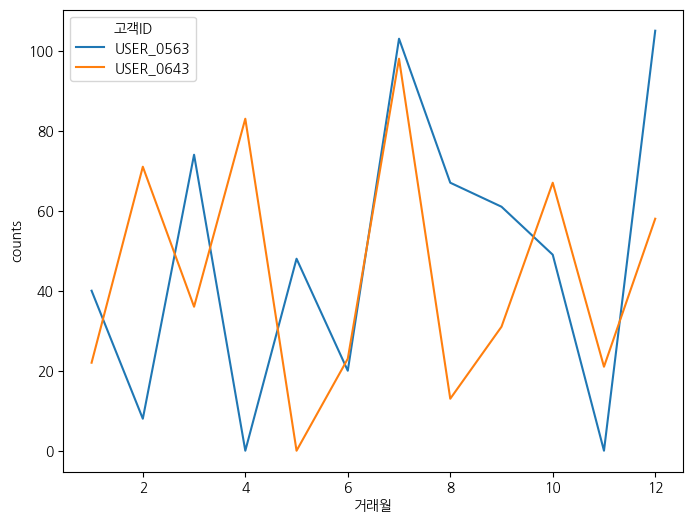

In [ ]:
plt.figure(figsize=(8,6))

sns.lineplot(data=vip_month_melt, x='거래월', y='counts', hue='고객ID')
plt.show()

두 고객 모두 구매가 잦아지는 주기가 2~3개월 정도로 비슷했다.

* USER_0563: 1월 -> 3월 -> 5월 -> 7월 -> 12월
* USER_0643: 2월 -> 4월 -> 7월 -> 10월 -> 12월

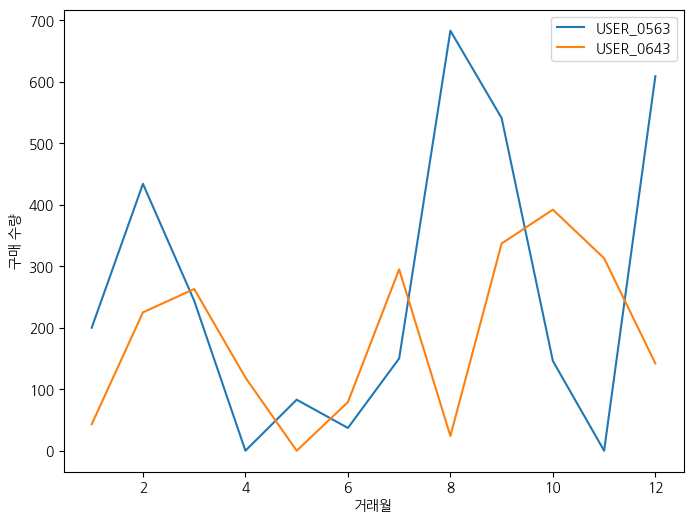

In [ ]:
# vip 고객 2명의 월별 구매 수량 파악
vip_monthly = vip.groupby(['고객ID', '거래월'])['수량'].sum().reset_index()

all_combinations = pd.MultiIndex.from_product([vip_monthly['고객ID'].unique(),
                                               np.arange(vip_monthly['거래월'].min(), vip_monthly['거래월'].max()+1)],
                                              names=['고객ID', '거래월']).to_frame(index=False)

vip_monthly = pd.merge(all_combinations, vip_monthly, on=['고객ID', '거래월'], how='left').fillna(0)

plt.figure(figsize=(8,6))
for user_id in ['USER_0563', 'USER_0643']:
    user_data = vip_monthly[vip_monthly['고객ID'] == user_id]
    plt.plot(user_data['거래월'], user_data['수량'], label=user_id)

plt.xlabel('거래월')
plt.ylabel('구매 수량')
plt.legend()
plt.show()

두 고객 모두 대량구매가 빈번히 존재하나, 주기는 불규칙적임을 알 수 있다. 또, USER_0643 고객이 대량구매 빈도는 더 높으나 USER_0563 고객이 한 번 대량구매시 더 많은 수량을 구매하는 것으로 나타났다.

* USER_0563: 2월 -> 8월 -> 9월 -> 12월
* USER_0643: 2월 -> 3월 -> 7월 -> 9월 -> 10월 -> 11월
=> VIP 고객들의 대량구매에 주목해서, 각 고객이 주로 대량구매하는 제품 카테고리를 확인해보았다.

In [ ]:
# USER_0563의 대량구매 품목
vip[vip['고객ID']=='USER_0563'].groupby(['거래ID', '제품카테고리'])['수량'].sum().sort_values(ascending=False).head(10)

,,수량
거래ID,제품카테고리,
Transaction_14371,Drinkware,500
Transaction_3764,Office,300
Transaction_17477,Drinkware,280
Transaction_22889,Apparel,245
Transaction_22890,Apparel,242
Transaction_16671,Apparel,136
Transaction_0986,Office,129
Transaction_3764,Lifestyle,100
Transaction_14368,Office,50


In [ ]:
# USER_0643의 대량구매 품목
vip[vip['고객ID'] == 'USER_0643'].groupby(['거래ID', '제품카테고리'])['수량'].sum().sort_values(ascending=False).head(10)

거래ID               제품카테고리     
Transaction_17774  Office         200
Transaction_20487  Accessories    193
Transaction_19989  Drinkware      124
Transaction_20487  Office         100
Transaction_2374   Office          90
Transaction_19989  Lifestyle       74
Transaction_4524   Drinkware       65
                   Office          65
Transaction_17774  Lifestyle       60
Transaction_12920  Drinkware       60
Name: 수량, dtype: int64

> 두 VIP 고객이 주로 대량으로 구매하는 카테고리는 비슷했으나, 조금의 차이점이 존재했다.

* USER_0563: Drinkware, Office, Apparel
* USER_0643: Office, Drinkware, Accessories

=> USER_0563 고객은 USER_0643 고객과 달리 Apparel 카테고리에 대한 대량구매가 잦았다.

=> USER_0643 고객은 USER_0563 고객과 달리 Accessories 카테고리를 대량으로 구매한 이력이 존재한다.

### 2-2. 충성고객

충성고객의 고객 수는 25명, 전체 고객의 1.7%

In [ ]:
loyal = df[df['segment']=='충성고객']

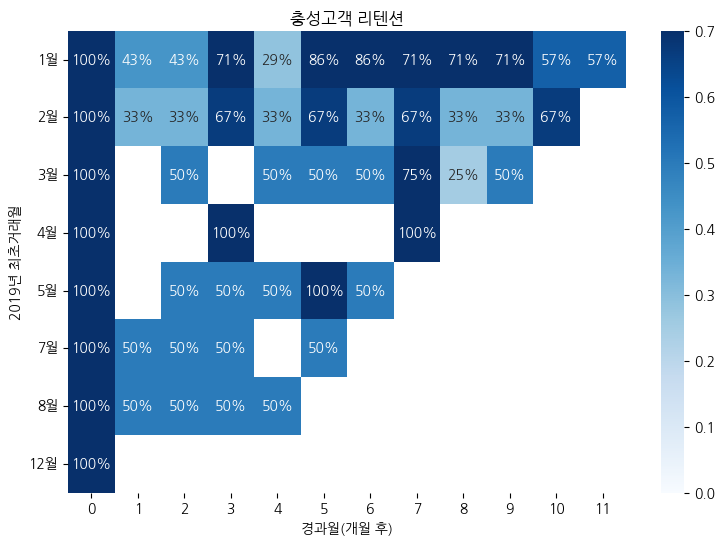

In [ ]:
#코호트 분석
cohort_one('충성고객 리텐션', loyal, 0.7)

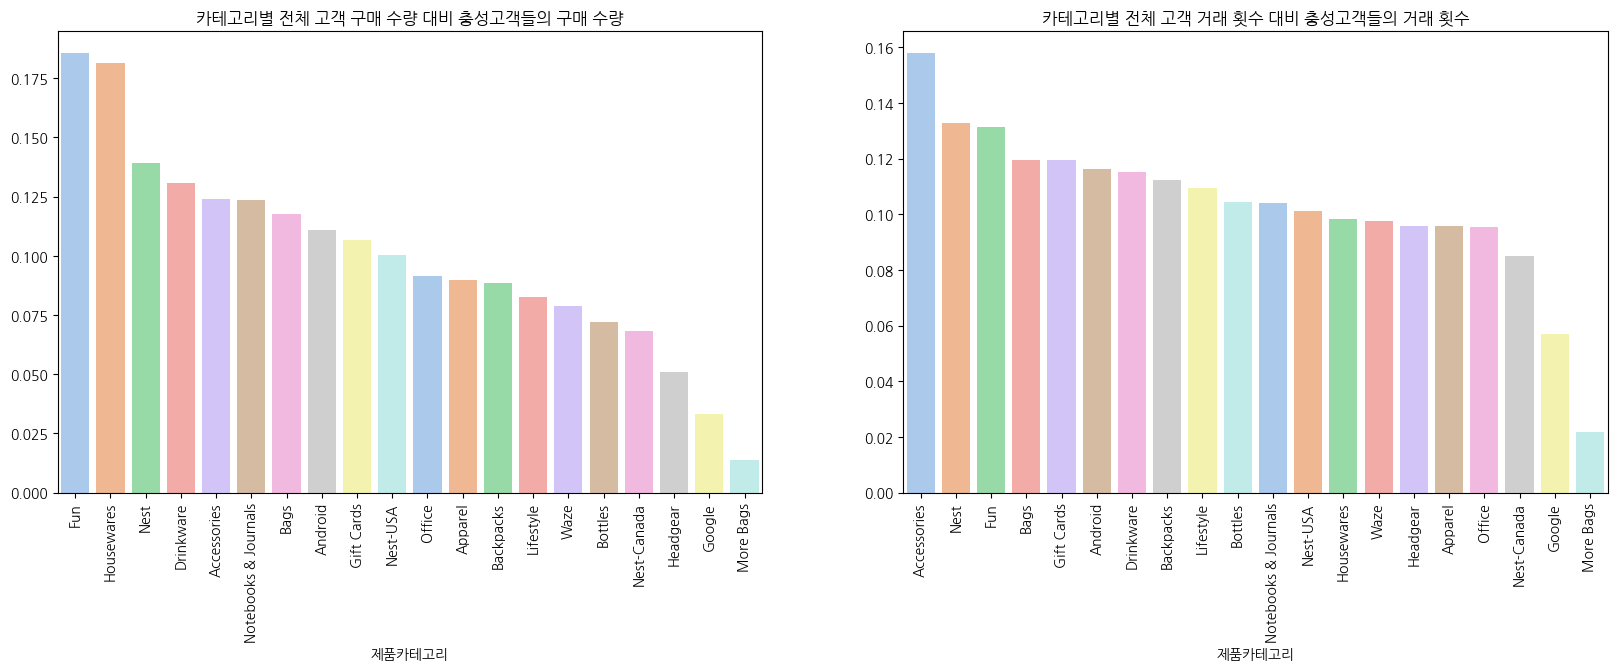

In [ ]:
# 전체 고객 대비 충성고객들이 자주, 많이 구매한 제품 카테고리 시각
f,ax = plt.subplots(1,2,figsize=(20,6))

cat = loyal.groupby('제품카테고리')['수량'].sum()/df.groupby('제품카테고리')['수량'].sum()
sorted_cat = cat.sort_values(ascending=False)
sns.barplot(x=sorted_cat.index, y=sorted_cat.values,ax=ax[0], palette='pastel')
ax[0].set_title('카테고리별 전체 고객 구매 수량 대비 충성고객들의 구매 수량')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)


cat2 = loyal['제품카테고리'].value_counts() / df['제품카테고리'].value_counts()
sorted_cat2 = cat2.sort_values(ascending=False)
sns.barplot(x=sorted_cat2.index, y=sorted_cat2.values,ax=ax[1], palette='pastel')
ax[1].set_title('카테고리별 전체 고객 거래 횟수 대비 충성고객들의 거래 횟수')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)
ax[1].set_xlabel('제품카테고리')

plt.show()

> 충성고객들은 구매 수량 측면에서도 전 카테고리의 10% 이상을 점유하고 있고, 거래 횟수 측면에서도 대부분 **10~12%**의 비중을 차지하고 있음을 알 수 있다.

* 구매 수량 측면에서 충성고객 비율이 가장 높은 Notebooks & Journals는 추가 분석 결과 소수 고객들의 대량구매에 의한 것으로 확인되었다. 실제로 구매 횟수 측면에서 충성고객의 비율은 중위권에 속하는 것을 알 수 있다. (오른쪽 그래프 참고)

* 거래 횟수 측면에서 충성고객 비율이 가장 높은 Accessories는 추가 분석 결과 대량구매는 없었으나, 소수의 고객들이 여러번 구매한 것으로 확인되었다.

=> 따라서, 전반적인 제품 카테고리별 구매 수량 및 거래 횟수로 보았을 때 충성고객들이 대체로 선호하는 제품 카테고리를 명확하게 알 수 없었다.

=> 수량 측면에서는 대량으로 구매한 고객들의 영향력이 커지므로, 월별로 쪼개서 전체 고객 대비 충성고객들의 카테고리별 구매 횟수를 확인하였다.

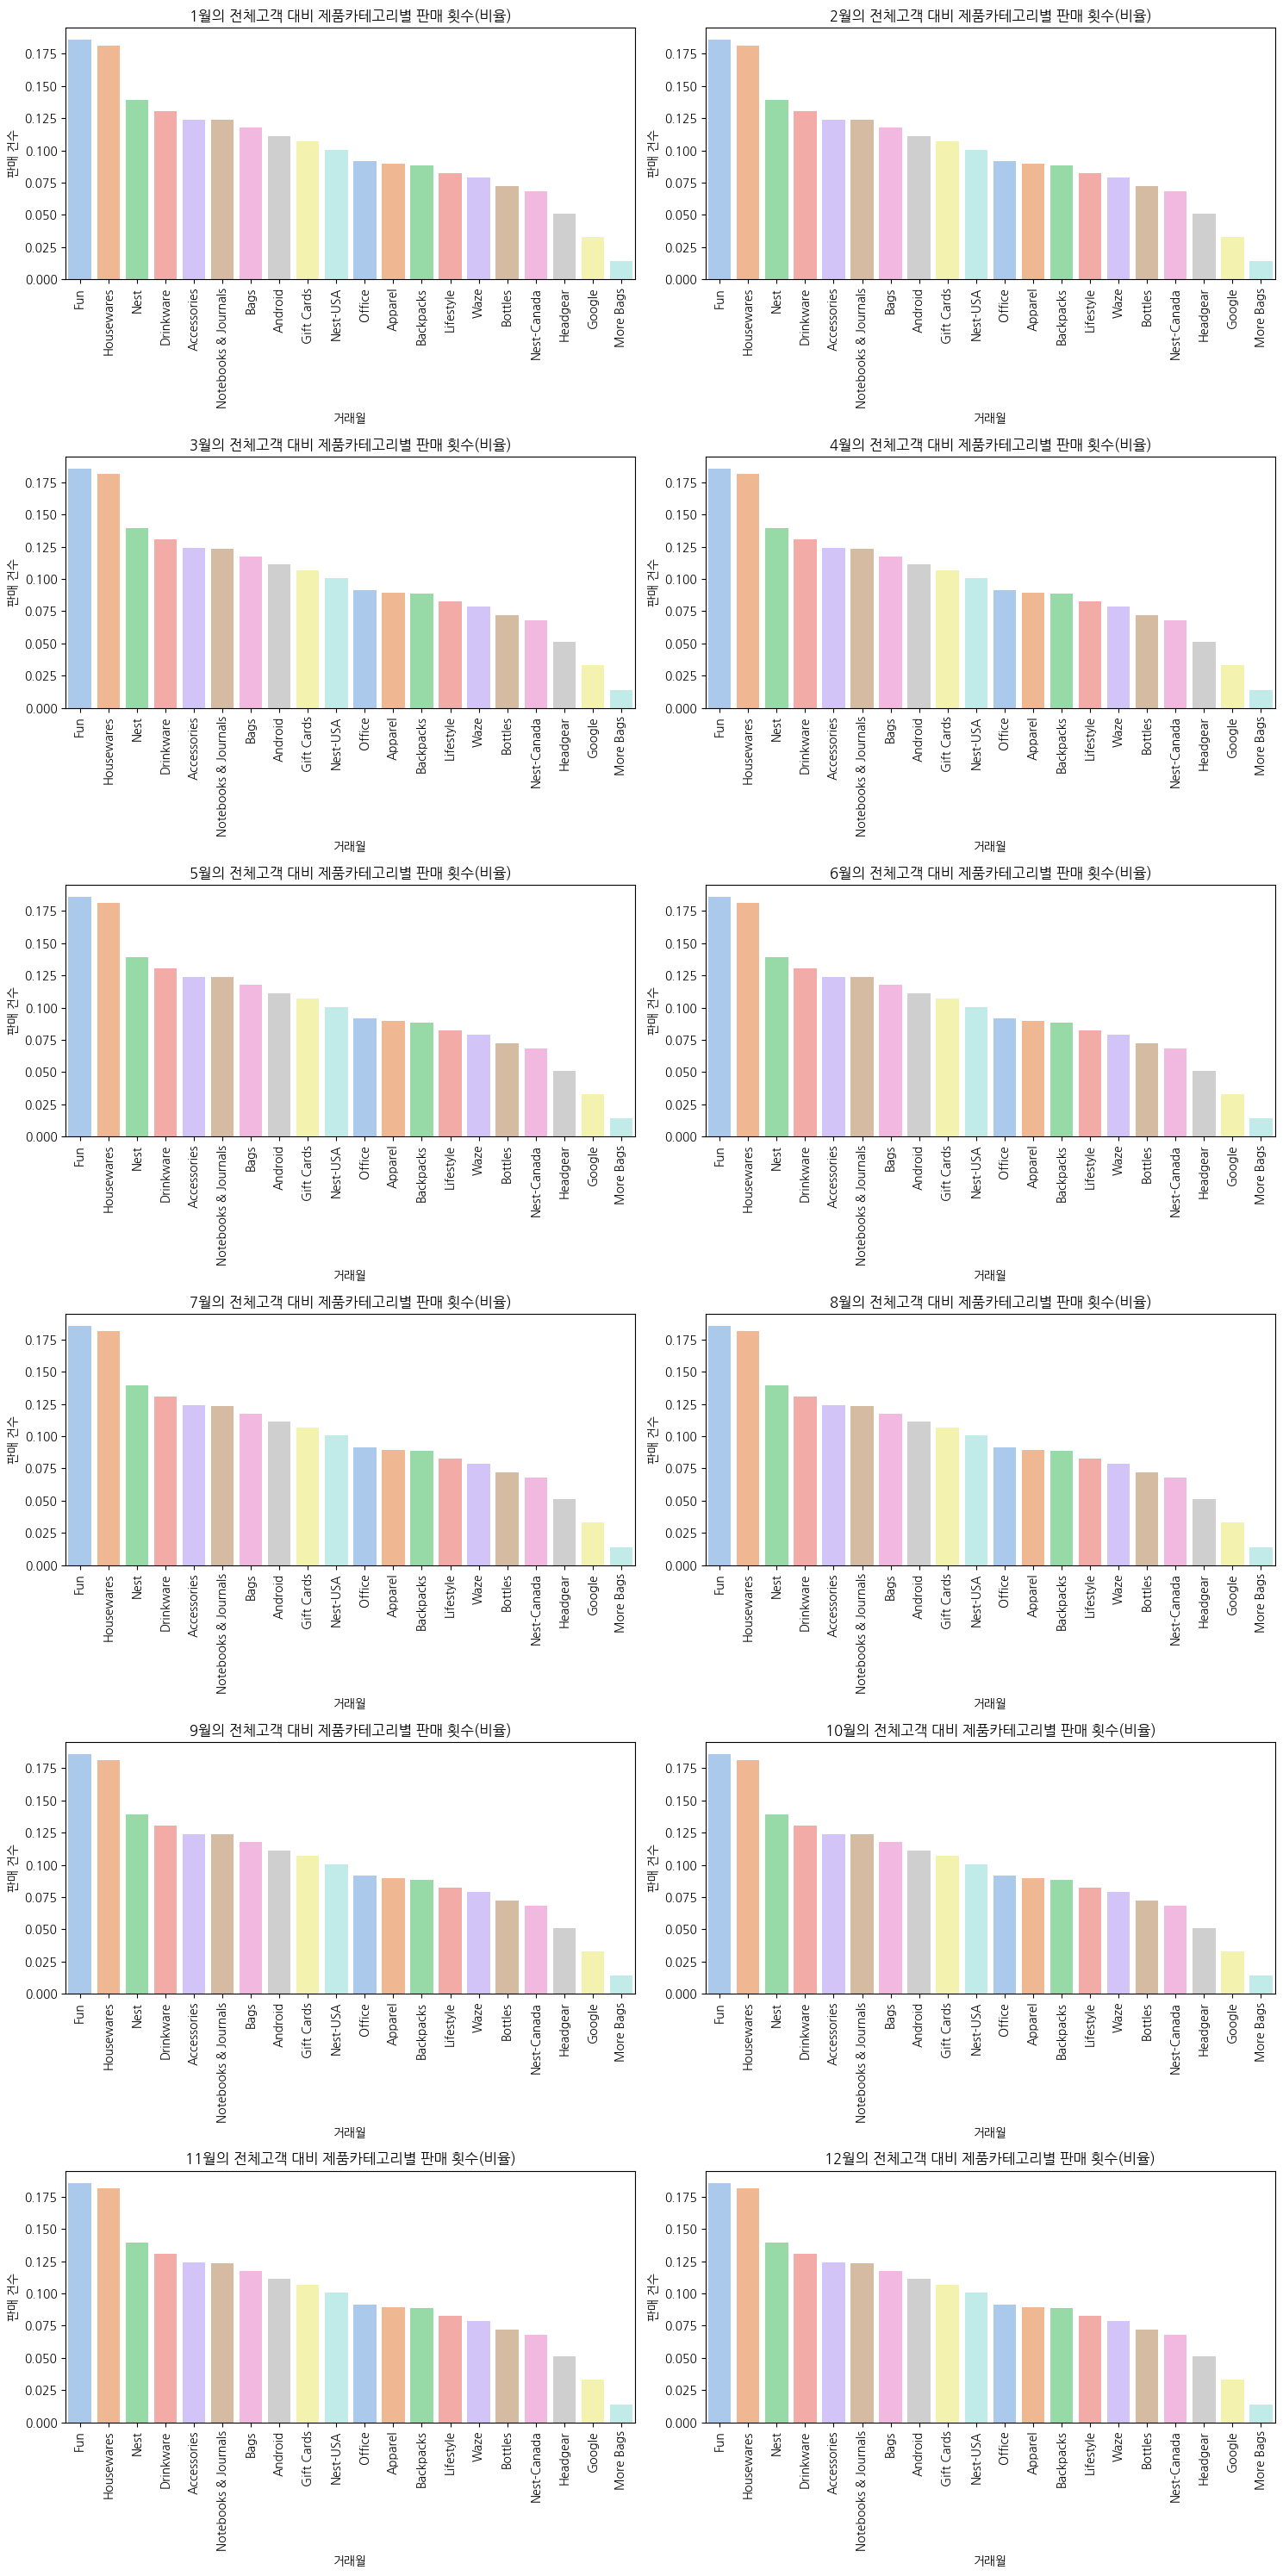

In [ ]:
# 월별 전체고객 구매 횟수 대비 충성고객들의 구매 횟수(비율) 시각화
fig, axs = plt.subplots(6,2, figsize=(15,30))
axs = axs.ravel()

for month in range(1,13):
  cat = loyal[loyal['거래월']==month]['제품카테고리'].value_counts() / df[df['거래월']==month]['제품카테고리'].value_counts()
  sns.barplot(x=sorted_cat.index, y=sorted_cat.values, palette='pastel', ax=axs[month-1])
  axs[month-1].set_title(f'{month}월의 전체고객 대비 제품카테고리별 판매 횟수(비율)')
  axs[month-1].set_ylabel('판매 건수')
  axs[month-1].set_xlabel('거래월')
  axs[month-1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

전체 고객 대비 충성고객들의 구매 빈도가 높은 제품들을 시각화해보니, 월별로 충성고객의 비율이 높은 제품이 명확하게 나타난다.

ex) 1월은 Notebooks & Journals, 6월은 Accessories

또, 월별로 충성고객 구매 비율 1위를 차지하는 제품 카테고리가 1년동안 거의 겹치는 경향 없이 다양하게 나타나는 것을 확인하였다.

### 2-3 잠재충성고객

* 잠재충성 고객 수는 216명, 전체 14% 차지함

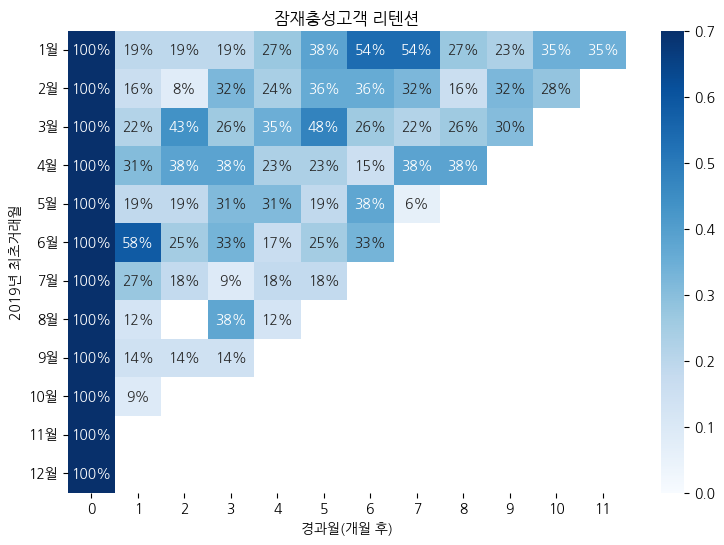

In [ ]:
# 코호트 분석
jc = df[df['segment'].isin(["잠재충성고객"])]
cohort_one('잠재충성고객 리텐션', jc, 0.7)

In [ ]:
# 연관부석에 필요한 컬럼을 따로 df_par 에 저장
df_apr = df[['고객ID', 'segment','제품카테고리', '수량']]

# 잠재충성고객을 대상으로 분석하므로 df_loy에 저장
df_loy = df_apr[df_apr['segment'] =='잠재충성고객']

In [ ]:
# 분석에 맞는 형태로 데이터 리스트화
loy = df_loy.groupby('고객ID')['제품카테고리'].apply(list).values.tolist()

In [ ]:
# 리스트 내 중복되는 요소 모두 제거
unique_lists=[]

for sublist in loy:
  unique_sublist=[]
  for item in sublist:
    if item not in unique_sublist:
      unique_sublist.append(item)
  unique_lists.append(unique_sublist)

# 제거 후 데이터 셋으로 이름을 바꿈
dataset = unique_lists

In [ ]:
# 트랜잭션 데이터를 이진 형태로 인코딩하여 희소 행렬을 생성
te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset, sparse=True)
te_df = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

In [ ]:
# Apriori 알고리즘 적용
frequent_itemset = apriori(te_df, min_support = 0.005,
                           max_len=3,
                           use_colnames=True,
                           verbose=1)
frequent_itemset['length']=frequent_itemset['itemsets'].map(lambda x:len(x))
frequent_itemset.sort_values('support',ascending=False,inplace=True)

Processing 3348 combinations | Sampling itemset size 3


In [ ]:
# 연관 규칙 찾기
association_rules_df=association_rules(frequent_itemset,
                                       metric='confidence',
                                       min_threshold=0.005,
                                       )

In [ ]:
# 조건부, 결과부, 지지도, 신뢰도, 향상도를 따로 loyal에 저장
loyal = association_rules_df[['antecedents','consequents', 'support', 'confidence', 'lift']]

# 최소지지도를 0.7로 설정하고, 향상도는 1 이상만 보기로 함
loyal=loyal[loyal['support']>0.7]
loyal=loyal[loyal['lift']>1]
loyal.sort_values(by='lift',ascending=False)

,antecedents,consequents,support,confidence,lift
111,(Office),"(Drinkware, Lifestyle)",0.860606,0.893082,1.030479
106,"(Drinkware, Lifestyle)",(Office),0.860606,0.993007,1.030479
119,"(Office, Bags)",(Drinkware),0.848485,0.972222,1.028312
122,(Drinkware),"(Office, Bags)",0.848485,0.897436,1.028312
107,"(Drinkware, Office)",(Lifestyle),0.860606,0.934211,1.027632
...,...,...,...,...,...
104,(Office),"(Bags, Apparel)",0.866667,0.899371,1.002677
140,"(Lifestyle, Office)",(Bags),0.812121,0.905405,1.002630
141,(Bags),"(Lifestyle, Office)",0.812121,0.899329,1.002630
102,"(Office, Apparel)",(Bags),0.866667,0.905063,1.002251


잠재충성고객 사이에서 가장 연관성 있는 제품 카테고리는 (Office, Bags)-> Lifestyle이다.

세 제품 카테고리 모두 구매한 고객 수가 전체의 79%이고, Office와 Bags 제품을 구매한 고객 중 Lifestyle도 구매한 고객 비율은 93%이고, 세 카테고리를 함께 마케팅 할 경우 약 5% 효과를 볼 수 있다.

### 2-4. 놓치면안될고객

* 놓치면안될고객의 고객 수는 42명, 전체 고객의 2%

In [ ]:
not_lost=df[df['segment']=='놓치면안될고객']

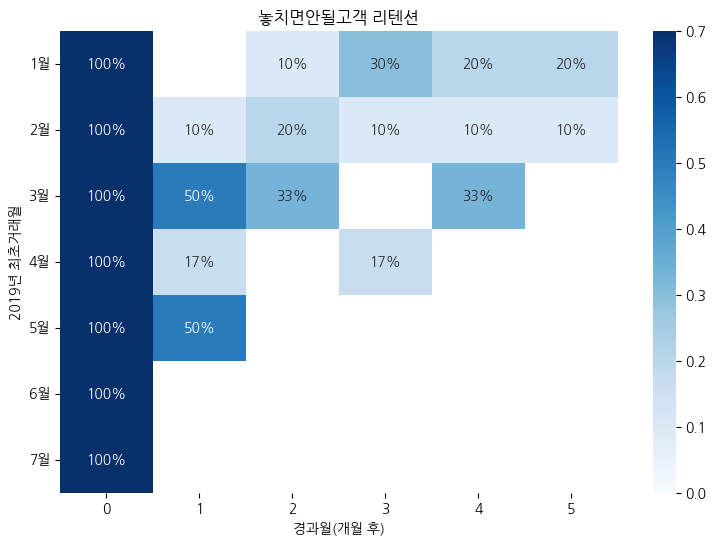

In [ ]:
#코호트 분석
cohort_one('놓치면안될고객 리텐션', not_lost, 0.7)

In [ ]:
not_lost['거래날짜'].max()

Timestamp('2019-07-17 00:00:00')

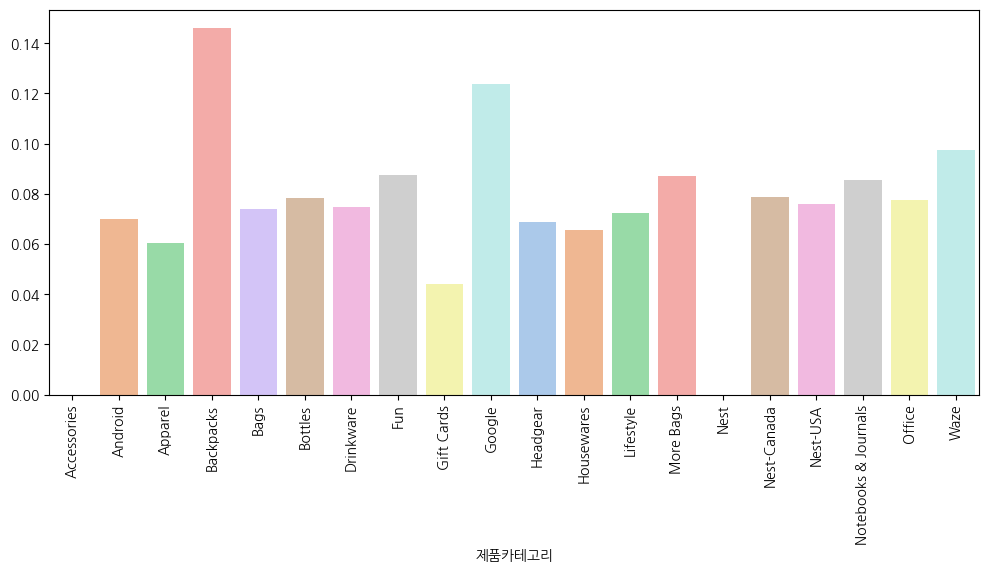

In [ ]:
# not_lost가 떠난 이유를 살펴보기 -> 자주 구매했던 카테고리 특정적으로 있는지 확인
# 전체대비 not_lost의 구매 이력 분포

plt.figure(figsize=(12,5))

not_lost_cat = not_lost['제품카테고리'].value_counts() / df['제품카테고리'].value_counts()
sns.barplot(x=not_lost_cat.index, y=not_lost_cat.values, palette='pastel')
plt.xticks(rotation=90)
plt.show()

Backpacks과 Google의 비율이 조금 높아서 추가로 확인해본 결과, 해당 카테고리의 거래량 자체가 많지 않고, 위에서 비율이 높은 이유는 소수 고객이 비교적 대량(40개)으로 구매했기 때문이다.

즉, 놓치면 안될 고객들이 특별하게 선호하는 제품은 없다고 볼 수 있다.

In [ ]:
# 고객ID별 거래날짜별 거래수량의 합
date_range=pd.date_range(start=not_lost['거래날짜'].min(),end=not_lost['거래날짜'].max())
index=pd.MultiIndex.from_product([date_range,not_lost['고객ID'].unique()],names=['거래날짜', '고객ID'])

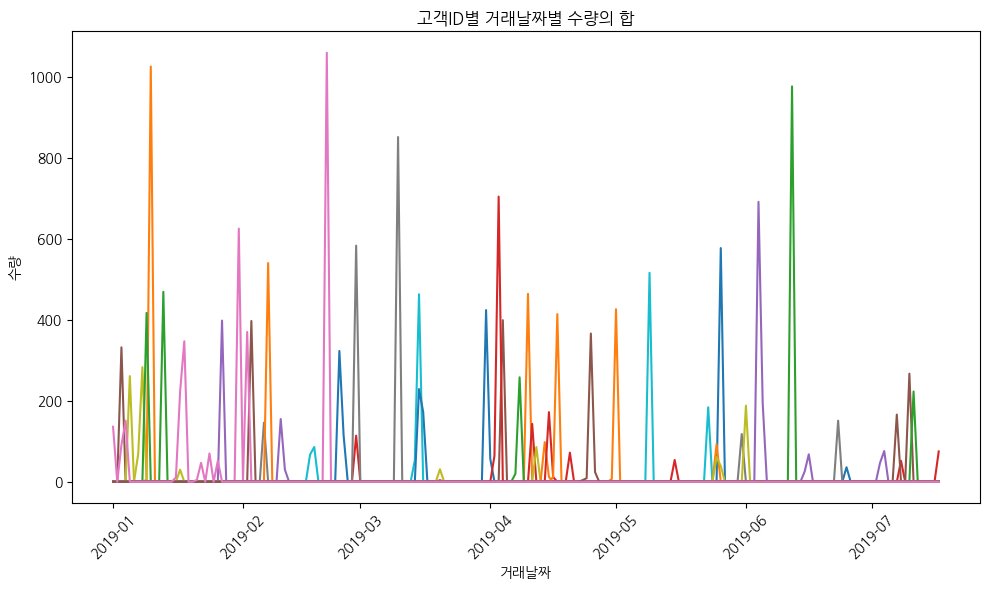

In [ ]:
filled_df = pd.DataFrame(index=index).reset_index()
filled_df = filled_df.merge(not_lost, on=['거래날짜', '고객ID'], how='left').fillna(0)

# 수량 컬럼만 선택하여 합계 계산 (날짜 덧셈 오류 방지)
grouped_df = filled_df.groupby(['거래날짜', '고객ID'])['수량'].sum().reset_index()

plt.figure(figsize=(10, 6))
for customer_id, group_data in grouped_df.groupby('고객ID'):
    plt.plot(group_data['거래날짜'], group_data['수량'], label=f'고객ID {customer_id}')

plt.title('고객ID별 거래날짜별 수량의 합')
plt.xlabel('거래날짜')
plt.ylabel('수량')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

위의 그래프를 보면, 고객ID별로 색상이 다른데, 구매 주기가 비교적 길고 주로 대량구매를 하는 것을 볼 수 있다.

### 2-5. 최근신규방문고객

* 최근신규방문고객의 고객 수는 451명, 전체 고객의 30%

In [ ]:
new=df[df['segment']=='최근신규방문고객']

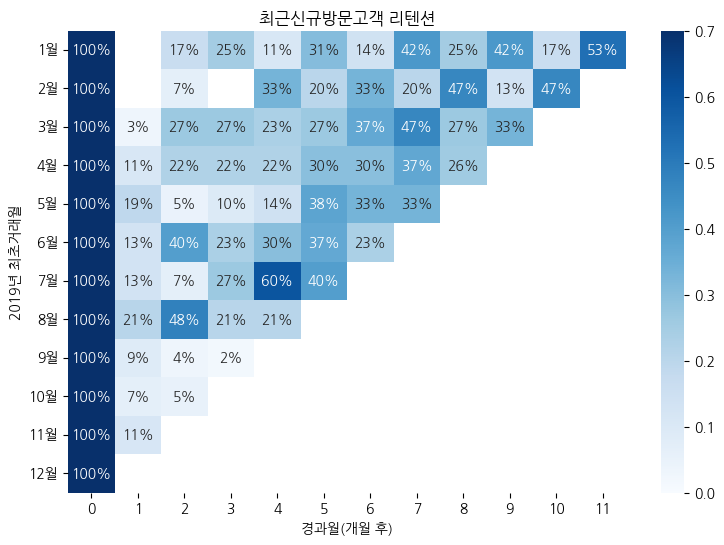

In [ ]:
# 코호트 분석
cohort_one('최근신규방문고객 리텐션', new, 0.7)

In [ ]:
new[new['가입년월'] < '2019-01-01']['고객ID'].nunique()
# 최근 새로 방문한 고객 451명 중 351명은 2019년 이전에 가입한 고객

387

In [ ]:
new[new['가입년월'] >= '2019-01-01']['고객ID'].nunique()
# 최근 새로 방문한 고객 451명 중 100명은 2019년에 가입한 고객

109

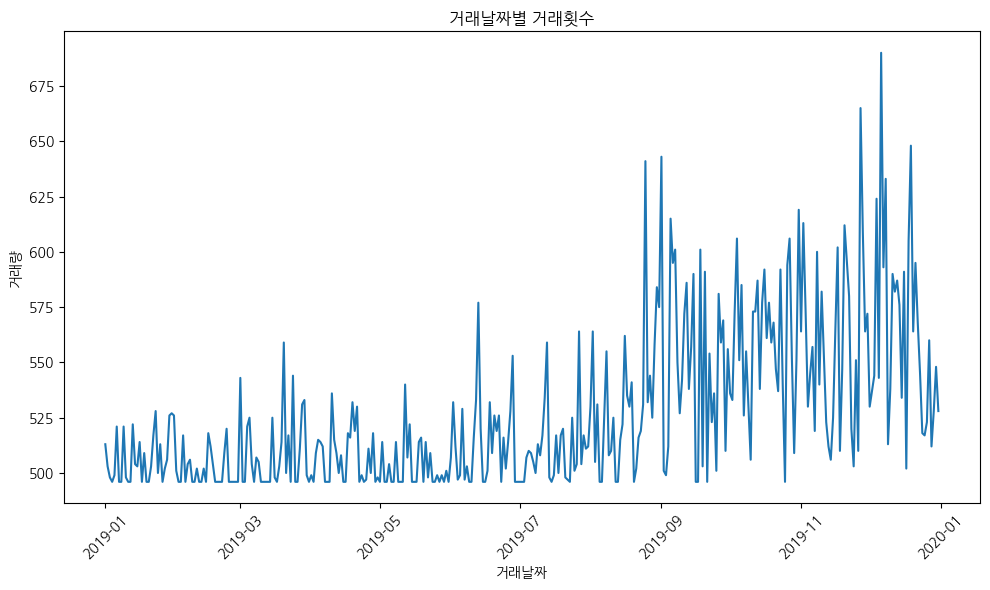

In [ ]:
# 거래날짜별 거래횟수 시각화

date_range = pd.date_range(start=new['거래날짜'].min(), end=new['거래날짜'].max())
index = pd.MultiIndex.from_product([date_range, new['고객ID'].unique()], names=['거래날짜', '고객ID'])
filled_df = pd.DataFrame(index=index).reset_index()
filled_df = filled_df.merge(new, on=['거래날짜', '고객ID'], how='left').fillna(0)
count_df = filled_df.groupby('거래날짜').size().reset_index(name='거래개수의합')

plt.figure(figsize=(10, 6))
plt.plot(count_df['거래날짜'], count_df['거래개수의합'])

plt.title('거래날짜별 거래횟수')
plt.xlabel('거래날짜')
plt.ylabel('거래량')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

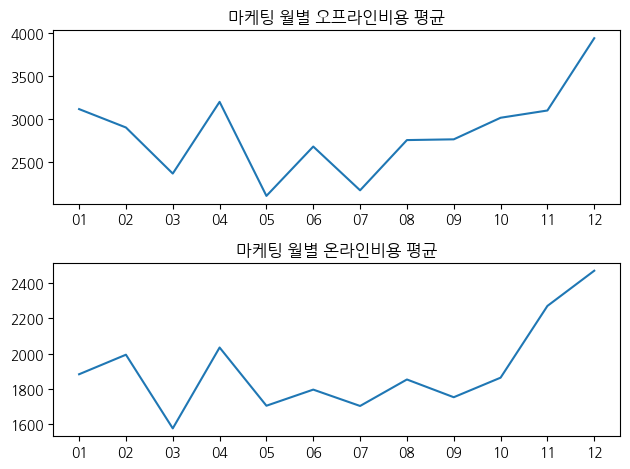

In [ ]:
# 월별 마케팅 비용 시각화

marketing['날짜'] = pd.to_datetime(marketing['날짜'])
marketing['mm'] = marketing['날짜'].dt.strftime('%m')
m_month = pd.DataFrame()
a = ['mm', '오프라인비용', '온라인비용']

for i in range(len(a)):
  m_month[a[i]] = marketing[a[i]]
mm_sum = pd.DataFrame()
mm_sum['오프라인비용'] = m_month.groupby('mm')['오프라인비용'].mean()
mm_sum['온라인비용'] = m_month.groupby('mm')['온라인비용'].mean()
mm_sum = mm_sum.reset_index(drop=False)

plt.subplot(2, 1, 1)
plt.plot(mm_sum['mm'], mm_sum['오프라인비용'])
plt.title('마케팅 월별 오프라인비용 평균')
plt.subplot(2, 1, 2)
plt.plot(mm_sum['mm'], mm_sum['온라인비용'])
plt.title('마케팅 월별 온라인비용 평균')
plt.tight_layout()
plt.show()

최근신규방문고객의 거래날짜별 거래횟수 그래프와 마케팅 비용 그래프를 비교해봤을때, 하반기의 마케팅 비용이 올라감에 따라 최근신규방문고객의 거래량이 늘어났다고 해석할 수 있다.

물론 최근신규방문고객의 최근 거래일인 하반기 데이터만 보았기 때문에 하반기 거래량이 많아보일 수 있다. 그러나 최근 신규방문고객의 R 지표는 최근 거래에만 영향을 끼치고, 이전에 거래를 했어도 상관이 없는 지표이다.

즉, 하반기 이전에 거래가 가능하였음에도 거래량이 증폭되는 것을 보아 하반기에 증가하는 마케팅 비용과 관련있다고 판단하였다. 특히, 마케팅 비용이 올라갈 수록 거래량이 증가하므로 값비싼 마케팅 전략에 유연한 고객층으로 해석된다.

In [ ]:
#첫거래에 가장 많이 구매하는 제품 카테고리
first=df[df['거래월']==df['최초거래월']]
first=first[first['경과월']==0]
first=first.sort_values(by='거래날짜')
first.drop_duplicates(subset='고객ID',inplace=True)
first

# 그 중 2019년 가입자만 first_2019에 저장
first_2019=first[first['가입년월'].dt.year==2019]
first_delivery_fee_by_customer

# 거래날짜에서 '첫거래월' 불러오기
first_2019['첫거래월'] = first_2019['거래날짜'].dt.month

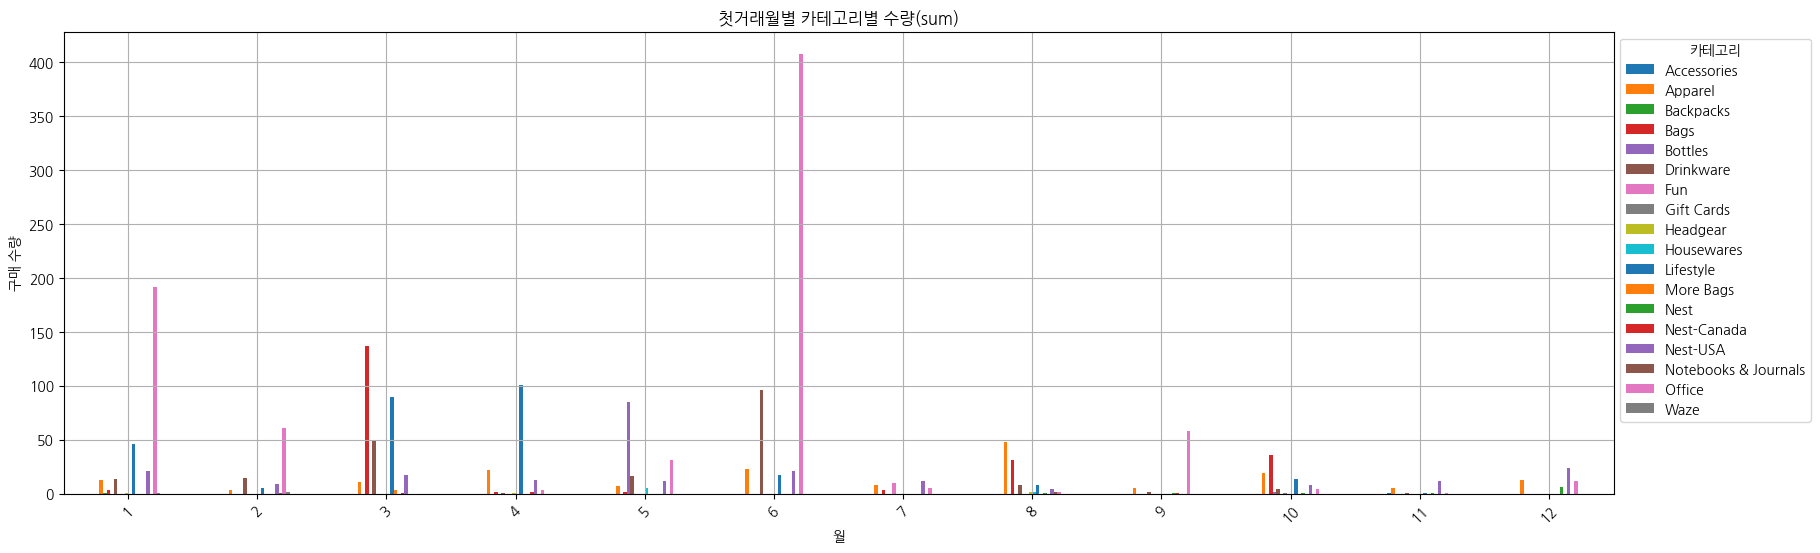

In [ ]:
# 첫거래월별 제품카테고리 수량을 pivot table로 생성
pivot_first_2019=first_2019.pivot_table(index='첫거래월', columns='제품카테고리', values='수량',aggfunc='sum')

pivot_first_2019.plot(kind='bar', figsize=(20,6))

plt.title('첫거래월별 카테고리별 수량(sum)')
plt.xlabel('월')
plt.ylabel('구매 수량')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='카테고리',loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

### 2-6. 이탈우려고객
* 이탈우려고객수는 246명, 전체 고객의 16.8%

In [ ]:
leaving_customers = df[df['segment'] == '이탈우려고객'].copy()
leaving_customers.head()

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,거래월,성별,고객지역,가입기간,쿠폰코드,할인율,GST,전체금액,지불금액,Recency,Frequency,Monetary,R,F,M,segment,최초거래월,경과월,가입년월,가입기간2,고객유형
26,USER_0066,Transaction_0009,2019-01-01,Product_0185,Office,1,2.47,102.79,Used,1,남,Chicago,33,OFF10,10.0,0.10,2.47,2.4453,187,15,2759.27496,2,1,1,이탈우려고객,1,0,2017-04-01,medium,기존고객
27,USER_0066,Transaction_0009,2019-01-01,Product_0879,Drinkware,26,8.72,102.79,Clicked,1,남,Chicago,33,EXTRA10,10.0,0.18,226.72,267.5296,187,15,2759.27496,2,1,1,이탈우려고객,1,0,2017-04-01,medium,기존고객
28,USER_0066,Transaction_0009,2019-01-01,Product_0904,Office,1,1.64,102.79,Clicked,1,남,Chicago,33,OFF10,10.0,0.10,1.64,1.8040,187,15,2759.27496,2,1,1,이탈우려고객,1,0,2017-04-01,medium,기존고객
29,USER_0066,Transaction_0009,2019-01-01,Product_1134,Office,1,1.64,102.79,Clicked,1,남,Chicago,33,OFF10,10.0,0.10,1.64,1.8040,187,15,2759.27496,2,1,1,이탈우려고객,1,0,2017-04-01,medium,기존고객
30,USER_0066,Transaction_0009,2019-01-01,Product_1142,Notebooks & Journals,26,7.93,102.79,Not Used,1,남,Chicago,33,NJ10,10.0,0.05,206.18,216.4890,187,15,2759.27496,2,1,1,이탈우려고객,1,0,2017-04-01,medium,기존고객


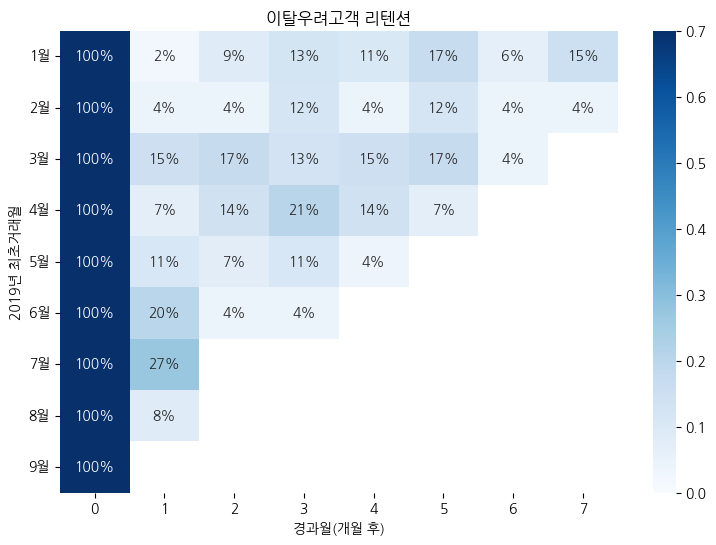

In [ ]:
# 코호트 분석
cohort_one('이탈우려고객 리텐션', leaving_customers, 0.7)

전체 카테고리를 기준으로 이탈우려고객이 해당 카테고리중 몇 퍼센트를 구매했는지 계산한다.

In [ ]:
# 이탈우려고객이 구매한 카테고리 비율

# 초록 배경
GREEN_BACKGROUND = '\033[42m'
RESET_STYLE = '\033[0m'

total_category_counts = df['제품카테고리'].value_counts()
leaving_category_counts = leaving_customers['제품카테고리'].value_counts()
leaving_category_ratios = leaving_category_counts / total_category_counts
sorted_ratios = leaving_category_ratios.sort_values(ascending=False)

highlighted = sorted_ratios.head(4)

# iteritems() -> items()로 변경
for category, value in highlighted.items():
    print(f'{GREEN_BACKGROUND}{category}: {value:.2%}{RESET_STYLE}')

rest_of_categories = sorted_ratios.iloc[4:]
rest_formatted = rest_of_categories.apply(lambda x: f'{x:.2%}' if x > 0 else '0.00%')
print(rest_formatted)

More Bags: 47.83%
Android: 34.88%
Google: 26.67%
Fun: 25.62%
제품카테고리
Housewares              25.41%
Nest-Canada             24.29%
Notebooks & Journals    21.50%
Office                  19.12%
Headgear                18.81%
Bottles                 18.66%
Apparel                 18.49%
Nest-USA                18.30%
Drinkware               18.23%
Bags                    17.96%
Lifestyle               16.36%
Gift Cards              16.35%
Backpacks               15.73%
Waze                    14.62%
Accessories              2.56%
Nest                     1.18%
Name: count, dtype: object


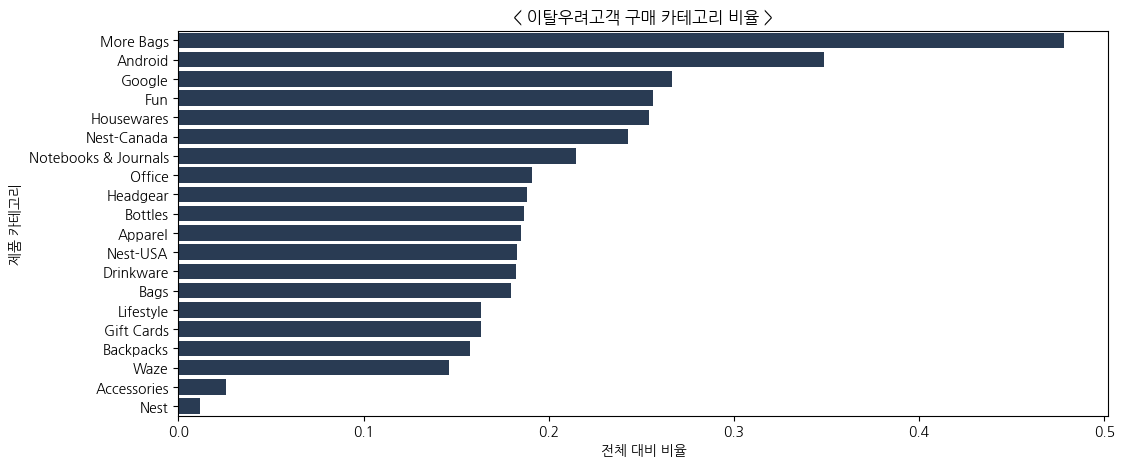

In [ ]:
# 위 내용을 시각화
dartb_color = ["#0B2447"]
base_color = sns.color_palette(dartb_color, n_colors=1)[0]

sorted_category_ratios=leaving_category_ratios.sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=sorted_category_ratios.values, y=sorted_category_ratios.index, color=base_color, alpha=0.9)
plt.title('< 이탈우려고객 구매 카테고리 비율 >')
plt.xlabel('전체 대비 비율')
plt.ylabel('제품 카테고리')
plt.show()

전반적으로 많이 구매하지 않는 카테고리인 ['Android', 'More Bags', 'Google', 'Housewares'] 가 상위권에 있음을 확인할 수 있다.
그리고 이 유형의 고객들의 가입년월을 확인하였다.

In [ ]:
# 전체 이탈우려고객의 가입년월
unique_customers = leaving_customers.drop_duplicates('고객ID')
unique_customers['가입년월'] = pd.to_datetime(unique_customers['가입년월'])
monthly_counts_unique = unique_customers['가입년월'].value_counts().sort_index()

# 2019년에 가입한 이탈우려고객
leaving_customers['가입년월'] = pd.to_datetime(leaving_customers['가입년월'])
customers_2019 = leaving_customers[leaving_customers['가입년월'].dt.year == 2019]
unique_customers_2019 = customers_2019.drop_duplicates('고객ID')
unique_customers_2019['가입년월'] = pd.to_datetime(unique_customers_2019['가입년월'])
monthly_counts_2019 = unique_customers_2019['가입년월'].value_counts().sort_index()

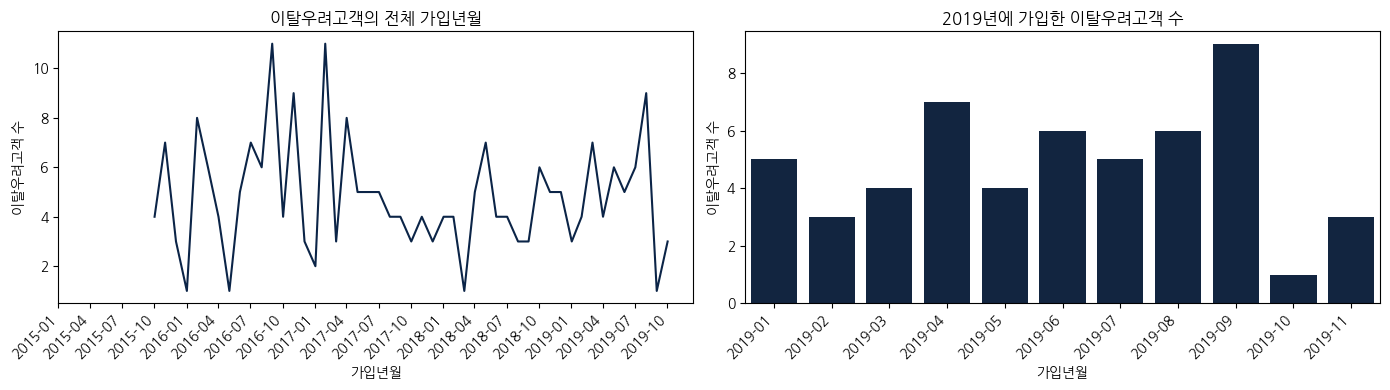

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 4))

sns.lineplot(x=monthly_counts_unique.index, y=monthly_counts_unique.values, color='#0B2447', ci=None, ax=axes[0])
axes[0].set_xticks(pd.date_range(start='2015-01-01', end='2019-12-31', freq='3M'))
axes[0].set_xticklabels(pd.date_range(start='2015-01-01', end='2019-12-31', freq='3M').strftime('%Y-%m'), rotation=45, ha='right')
axes[0].set_title('이탈우려고객의 전체 가입년월')
axes[0].set_xlabel('가입년월')
axes[0].set_ylabel('이탈우려고객 수')

sns.barplot(x=monthly_counts_2019.index.strftime('%Y-%m'), y=monthly_counts_2019.values, color='#0B2447', ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_title('2019년에 가입한 이탈우려고객 수')
axes[1].set_xlabel('가입년월')
axes[1].set_ylabel('이탈우려고객 수')

plt.tight_layout()
plt.show()

오래전에 가입한 고객들부터 최신(2019년)에 가입한 고객들까지 다양하게 나타난 편이다.

그렇다면, 이탈우려고객들 사이에서는 전체 대비 구매 비율이 높았던 카테고리를 얼마나 구매했는지 알아보자.

In [ ]:
# 이탈우려고객이 구매한 각 카테고리의 수량
leaving_category_counts = leaving_customers['제품카테고리'].value_counts()
leaving_category_ratios = leaving_category_counts / leaving_category_counts.sum() * 100
sorted_leaving_category_ratios = leaving_category_ratios.sort_values(ascending=False)

print("이탈우려고객이 구매한 카테고리의 비율:")
print(sorted_leaving_category_ratios.round(2))



이탈우려고객이 구매한 카테고리의 비율:
제품카테고리
Apparel                 35.80
Nest-USA                27.39
Office                  13.30
Drinkware                6.78
Lifestyle                5.40
Bags                     3.61
Notebooks & Journals     1.72
Headgear                 1.55
Waze                     0.87
Nest-Canada              0.82
Bottles                  0.53
Fun                      0.44
Housewares               0.33
Google                   0.30
Gift Cards               0.28
Nest                     0.28
More Bags                0.23
Android                  0.16
Backpacks                0.15
Accessories              0.06
Name: count, dtype: float64


전체 대비 구매 카테고리 비율이 높았던 4가지의 경우, 모두 이탈우려고객들 사이에서 구매한 비율이 1% 미만으로 나타났고 심지어 하반기에 판매하지 않은 경우도 많다.
즉, 이탈우려고객들이 상대적으로 많은 구매 비율을 차지했던 카테고리가 해당 고객들 사이에서 많은 거래가 이루어지지 않고, 거래가 이루어지더라도 이탈이 우려되는 고객이므로 이 기업은 앞서 확인한 4가지의 카테고리를 판매하기위한 구체적인 전략을 세울 필요가 없다고 판단했다.

### 종합 마케팅

#### 3-1. 지역 및 요일 분석

전체 데이터를 기준으로 요일별로 거래량을 파악하였다.

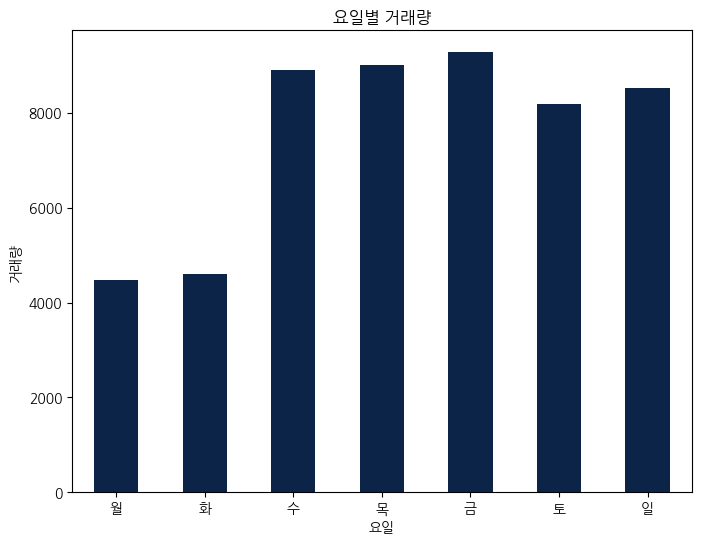

In [ ]:
df['거래날짜']=pd.to_datetime(df['거래날짜'])
df['요일']=df['거래날짜'].dt.dayofweek
transaction_by_day = df['요일'].value_counts().sort_index()

day_names = ['월', '화', '수', '목', '금', '토', '일']
transaction_by_day.index=transaction_by_day.index.map(lambda x:day_names[x])

plt.figure(figsize=(8,6))
transaction_by_day.plot(kind='bar', rot=0, color='#0B2447')
plt.title('요일별 거래량')
plt.xlabel('요일')
plt.ylabel('거래량')
plt.show()

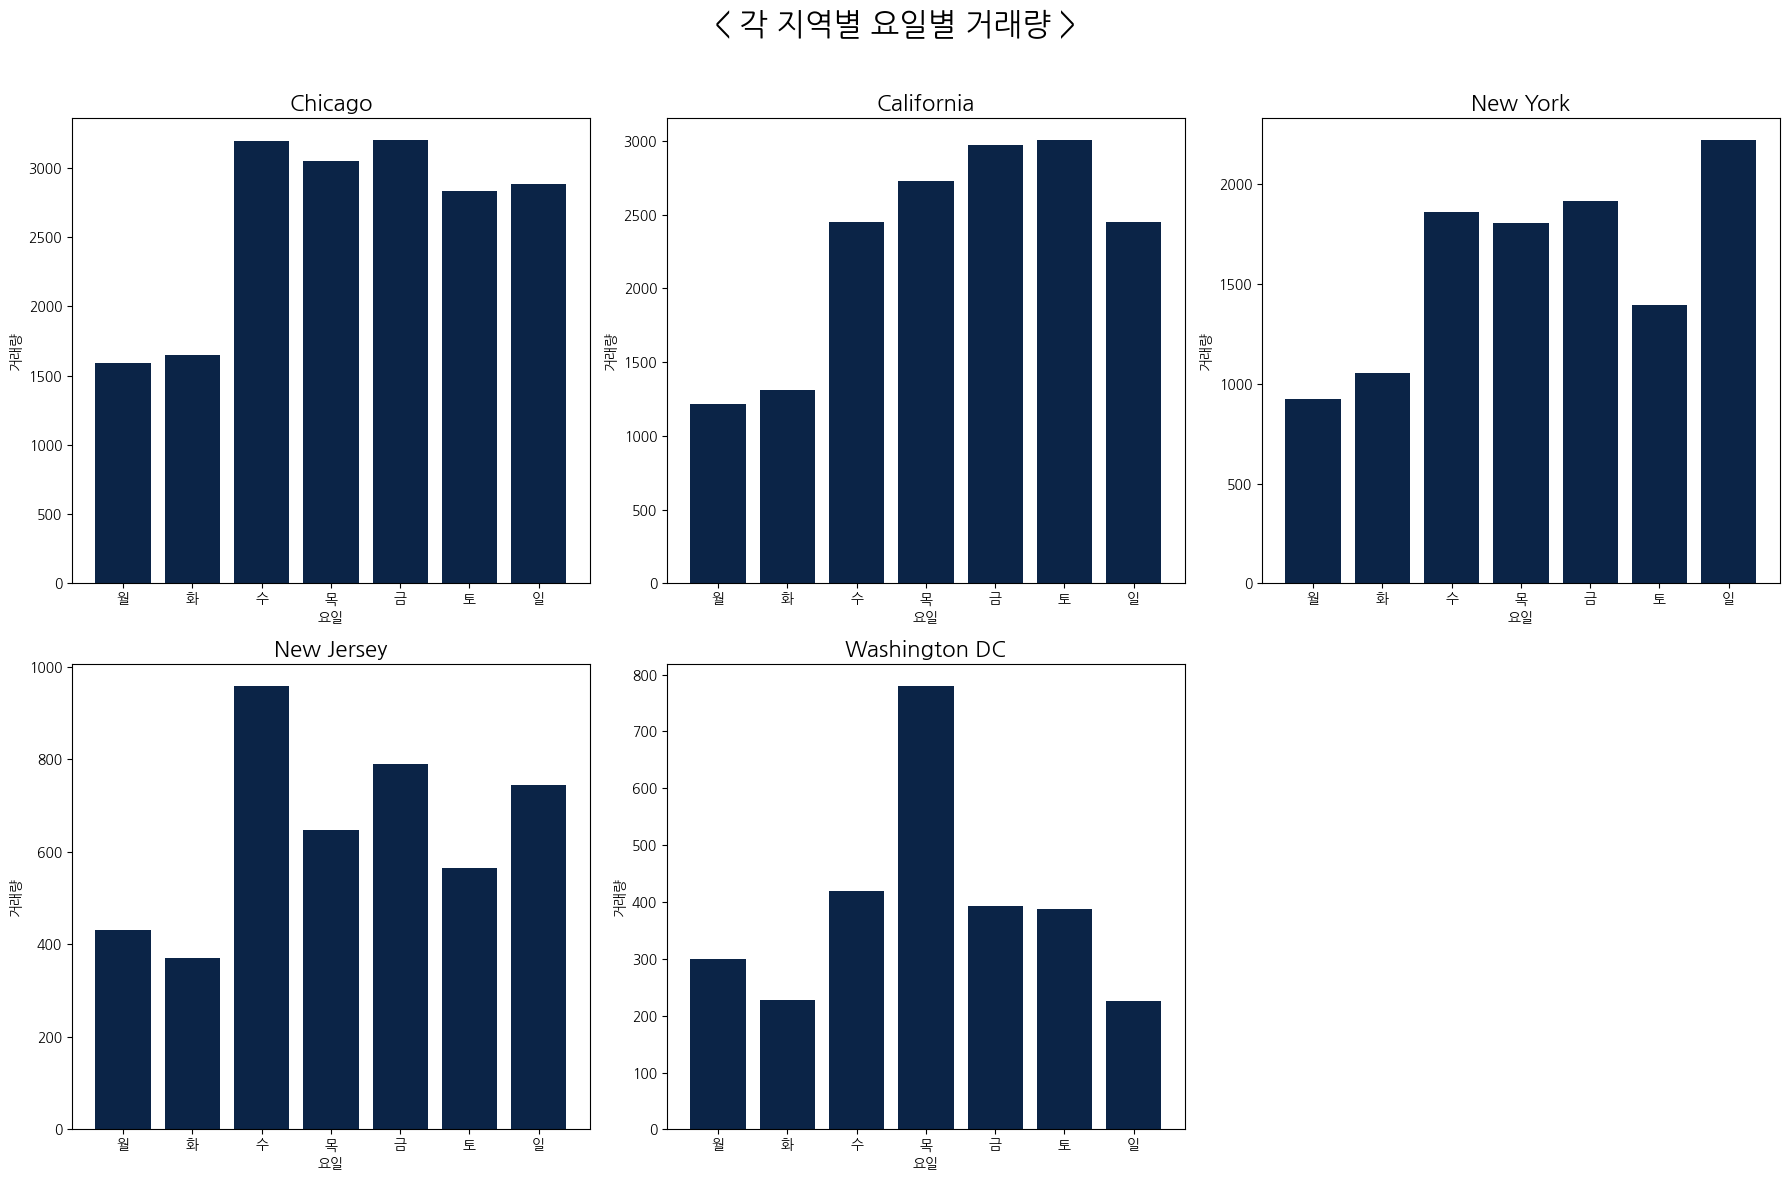

In [ ]:
df['거래날짜'] = pd.to_datetime(df['거래날짜'])
df['요일'] = df['거래날짜'].dt.day_name()

day_counts_by_region = df.groupby(['고객지역', '요일']).size().unstack()

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
fig.suptitle('< 각 지역별 요일별 거래량 >', fontsize=22)

regions = ['Chicago', 'California', 'New York', 'New Jersey', 'Washington DC']
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_labels_korean = ['월', '화', '수', '목', '금', '토', '일']

region_required_data = day_counts_by_region.reindex(regions).fillna(0)

for i, (region, ax) in enumerate(zip(regions, axes.flatten())):
    day_counts = region_required_data.loc[region]
    day_counts = day_counts.reindex(day_order).fillna(0)
    ax.bar(day_labels_korean, day_counts, color='#0B2447')

    ax.set_title(region, fontsize=16)
    ax.set_xlabel('요일')
    ax.set_ylabel('거래량')
    ax.set_xticks(range(len(day_labels_korean)))
    ax.set_xticklabels(day_labels_korean, rotation=0)

for j in range(i+1, 6):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Chicago, California, New Jersey는 전체 데이터 흐름과 비슷한 양상을 보였다.
New York의 경우 일요일에 거래되는 횟수가 가장 많았으며, 토/월에 상대적으로 작은 거래가 진행되므로 일요일에 특별한 이벤트나 행사가 진행되었을 것이다. 또한, Washington DC의 경우 목요일에 압도적으로 거래량이 많았기 때문에 해당 요일에 특정 이벤트가 진행되었을 것으로 추측할 수 있다.

그렇다면 각 지역에서 많이 판매된 카테고리와 금액을 살펴보자.

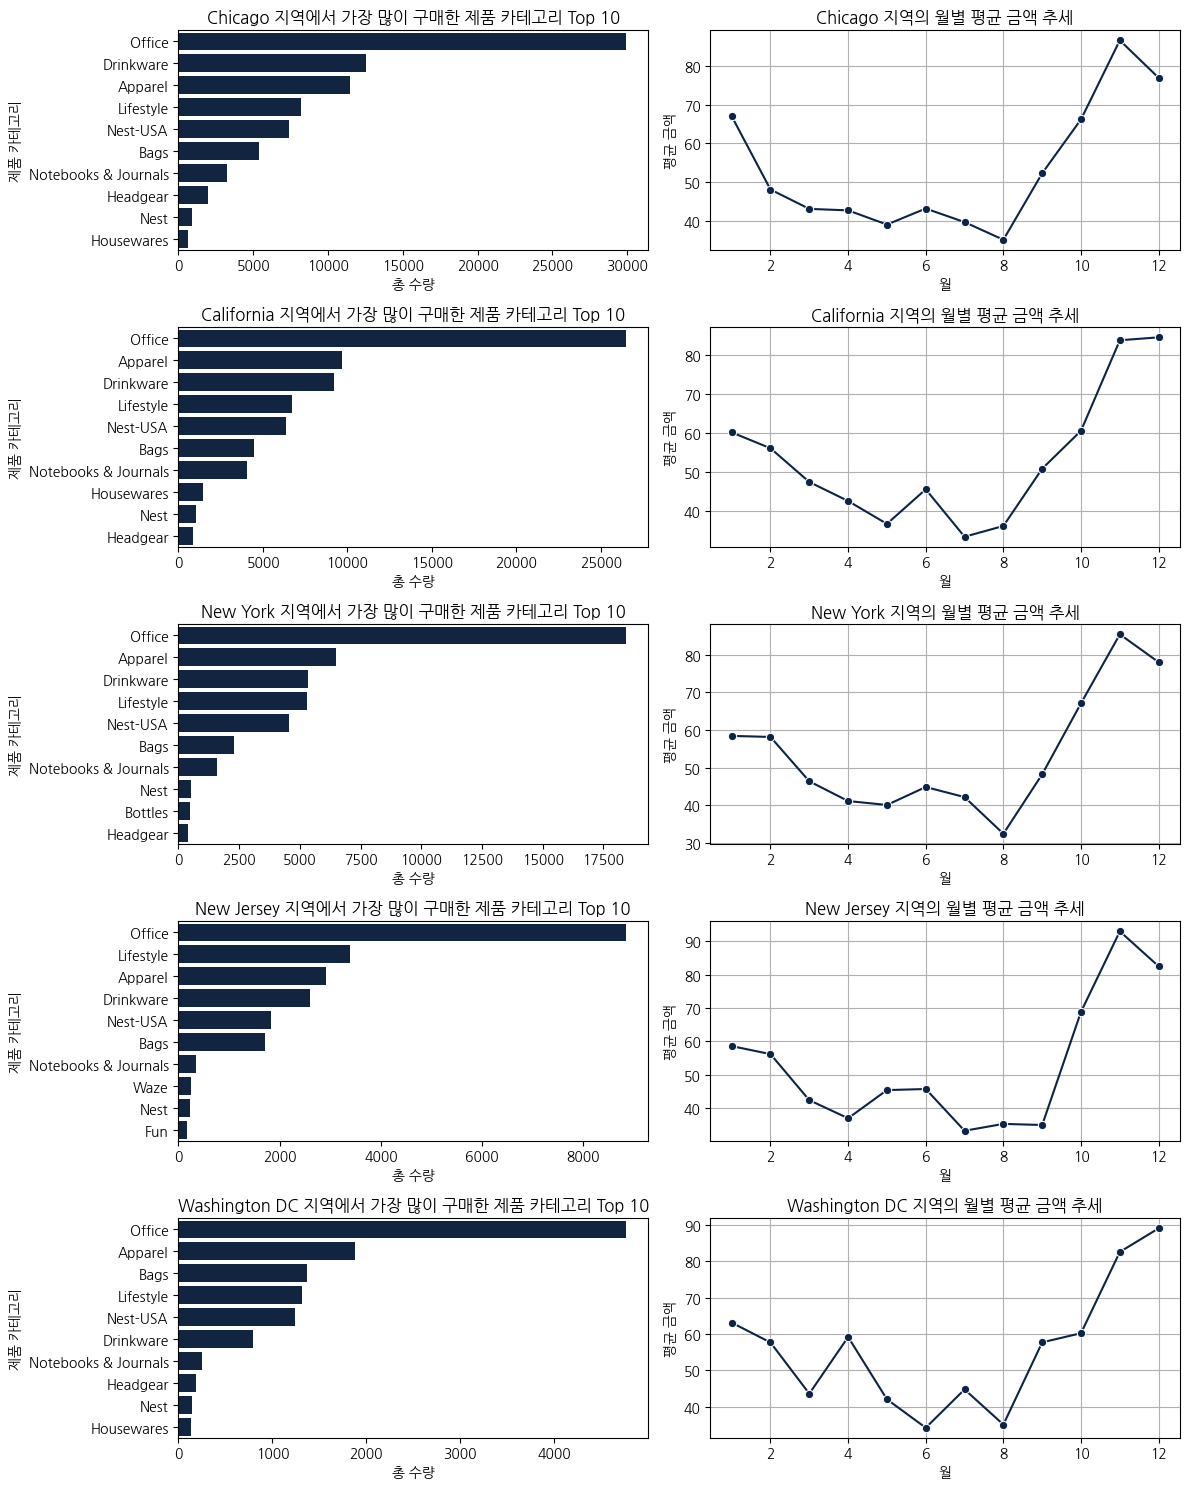

In [ ]:
fig, axes = plt.subplots(len(regions), 2, figsize=(12, 3 * len(regions)))

for i, region in enumerate(regions):
    df_region = df[df['고객지역'] == region]

    if '월' not in df_region.columns:
        df_region['월'] = df_region['거래월']

    category_total_quantity = df_region.groupby('제품카테고리')['수량'].sum().reset_index()
    category_total_quantity_sorted = category_total_quantity.sort_values(by='수량', ascending=False)

    sns.barplot(ax=axes[i, 0], x='수량', y='제품카테고리', data=category_total_quantity_sorted.head(10), color="#0B2447")
    axes[i, 0].set_title(f'{region} 지역에서 가장 많이 구매한 제품 카테고리 Top 10')
    axes[i, 0].set_xlabel('총 수량')
    axes[i, 0].set_ylabel('제품 카테고리')

    monthly_avg_amount = df_region.groupby('월')['평균금액'].mean().reset_index()

    sns.lineplot(ax=axes[i, 1], x='월', y='평균금액', data=monthly_avg_amount, marker='o', color="#0B2447")
    axes[i, 1].set_title(f'{region} 지역의 월별 평균 금액 추세')
    axes[i, 1].set_xlabel('월')
    axes[i, 1].set_ylabel('평균 금액')
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()

추가적으로, segment별로 어떤 요일에 많이 구매를 했는지 파악해보았다.

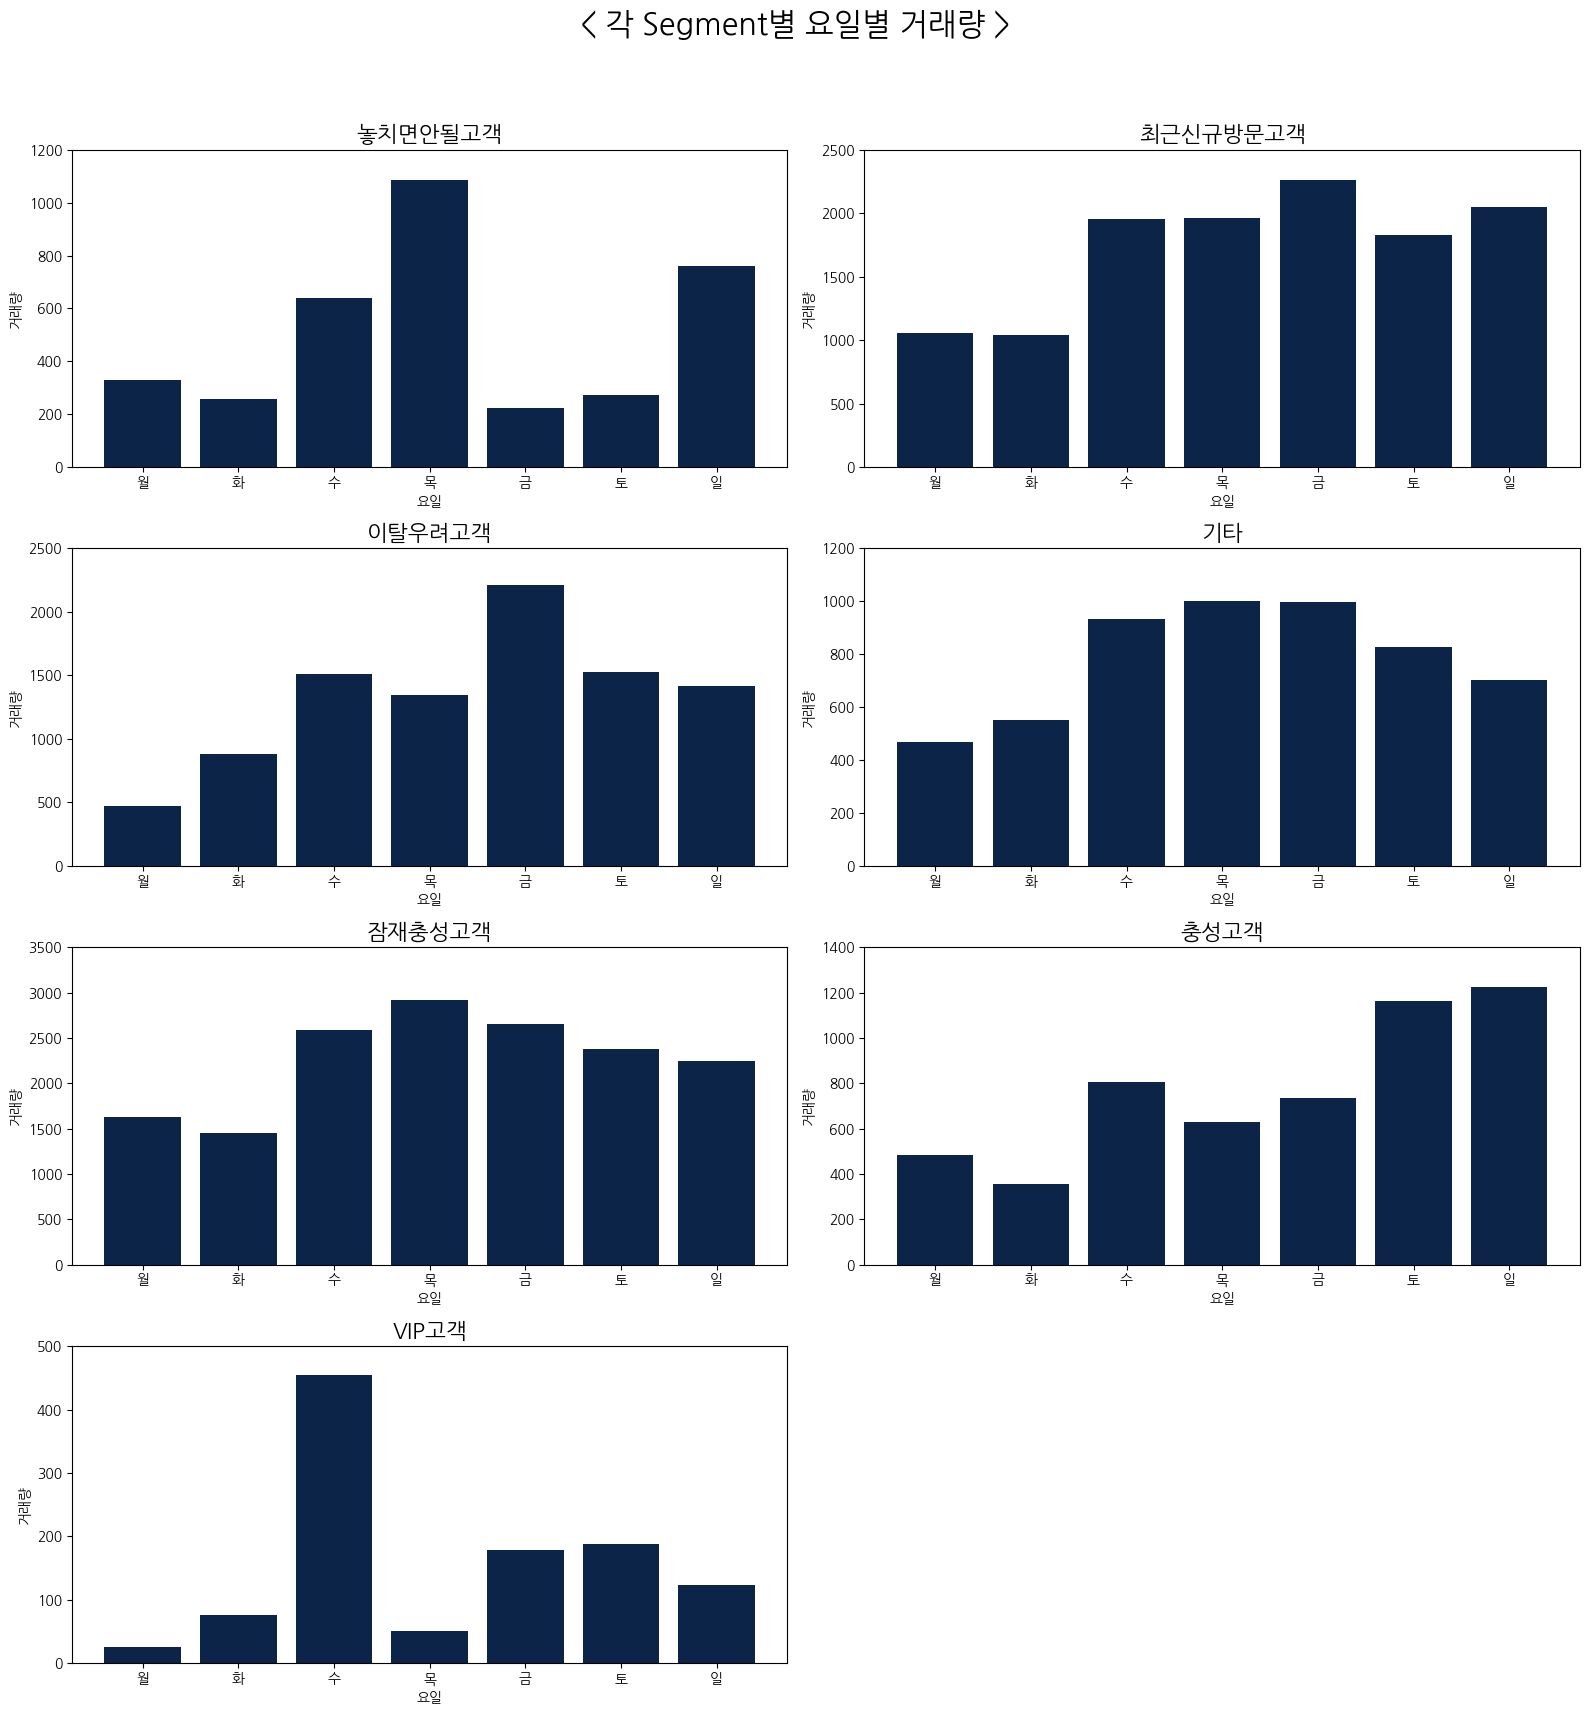

In [ ]:
df['거래날짜'] = pd.to_datetime(df['거래날짜'])
df['요일'] = df['거래날짜'].dt.day_name()
day_counts_by_segment = df.groupby(['segment', '요일']).size().unstack()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_labels_korean = ['월', '화', '수', '목', '금', '토', '일']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 18))
fig.suptitle('< 각 Segment별 요일별 거래량 >', fontsize=22)

segments = ['놓치면안될고객', '최근신규방문고객', '이탈우려고객', '기타', '잠재충성고객', '충성고객', 'VIP고객']
for i, (segment, ax) in enumerate(zip(segments, axes.ravel())):
    day_counts = day_counts_by_segment.loc[segment]
    day_counts = day_counts.reindex(day_order).fillna(0)

    ax.bar(day_labels_korean, day_counts, color='#0B2447')

    ax.set_title(segment, fontsize=16)
    ax.set_xlabel('요일')
    ax.set_ylabel('거래량')
    ax.set_xticks(range(len(day_labels_korean)))
    ax.set_xticklabels(day_labels_korean, rotation=0)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(ax.get_yticklabels())

axes[-1, -1].axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

분석 결과 모든 지역에서 공통적으로 거래량이 저조했던 요일인 월, 화에 할인쿠폰 제공 등의 프로모션을 진행하는 마케팅 전략을 제시해 볼 수 있다.

### 3-2. 비회원 분석

In [ ]:
# 비회원
n_member = df[df['거래날짜']<df['가입년월']]['고객ID'].unique()
nm_df=df[df['고객ID'].isin(n_member)]

In [ ]:
nm_df['고객ID'].nunique()

158

고객별로 가입일 이전과 이후의 거래 데이터 횟수를 계산한다.

In [ ]:
def count_transactions_before_and_after_join(df):
    counts_before_join = {}
    counts_after_join = {}

    for customer_id, group in df.groupby('고객ID'):
      join_date = group['가입년월'].iloc[0]
      # 가입일 이전 거래 횟수
      before_join_count=group[group['거래날짜']<join_date].shape[0]
      # 가입일 이후 거래 횟수
      after_join_count=group[group['거래날짜']>=join_date].shape[0]

      counts_before_join[customer_id]=before_join_count
      counts_after_join[customer_id]=after_join_count
    return counts_before_join, counts_after_join

#가입일 이전과 이후의 거래 횟수를 계산
counts_before_join, counts_after_join = count_transactions_before_and_after_join(nm_df)

result_df = pd.DataFrame({
    '고객ID': list(counts_before_join.keys()),
    '이전 거래횟수': list(counts_before_join.values()),
    '이후 거래횟수': list(counts_after_join.values())
})

In [ ]:
result_df

,고객ID,이전 거래횟수,이후 거래횟수
0,USER_0013,12,20
1,USER_0033,1,127
2,USER_0034,126,0
3,USER_0042,15,0
4,USER_0067,74,0
...,...,...,...
153,USER_1431,1,0
154,USER_1442,44,0
155,USER_1458,1,0
156,USER_1460,27,28


In [ ]:
# 이전 거래횟수가 0인 고객
uu = result_df[result_df['이후 거래횟수']==0]['고객ID']
len(uu)

104

In [ ]:
# 위의 고객들의 거래날짜 개수
nm_df[nm_df['고객ID'].isin(uu)].groupby(['고객ID'])['거래날짜'].nunique()

,거래날짜
고객ID,
USER_0034,3
USER_0042,1
USER_0067,2
USER_0068,1
USER_0105,2
...,...
USER_1421,1
USER_1431,1
USER_1442,3


가입 이후 거래하지 않은 고객들(104명)의 거래날짜 개수를 출력하면 1~5이고, 대부분 1이다.
즉, 단기간 거래하고 거래하지 않다가 가입만 한 고객들이다.

In [ ]:
latest_transactions = nm_df[nm_df['고객ID'].isin(uu) & (nm_df['거래날짜'] < nm_df['가입년월'])].groupby('고객ID').agg({
    '거래날짜': 'max',
    '가입년월': 'first'
})

latest_transactions['가입년월'] = pd.to_datetime(latest_transactions['가입년월'])
latest_transactions['거래날짜'] = pd.to_datetime(latest_transactions['거래날짜'])
latest_transactions['가입년월-거래날짜'] = latest_transactions['가입년월'] - latest_transactions['거래날짜']

In [ ]:
latest_transactions

,거래날짜,가입년월,가입년월-거래날짜
고객ID,,,
USER_0034,2019-10-30,2019-11-01,2 days
USER_0042,2019-08-03,2019-11-01,90 days
USER_0067,2019-07-24,2019-09-01,39 days
USER_0068,2019-03-04,2019-10-01,211 days
USER_0105,2019-07-06,2019-08-01,26 days
...,...,...,...
USER_1421,2019-01-02,2019-03-01,58 days
USER_1431,2019-03-08,2019-10-01,207 days
USER_1442,2019-06-05,2019-08-01,57 days


In [ ]:
latest_transactions['가입년월'].value_counts().sort_index()

,count
가입년월,
2019-02-01,1
2019-03-01,3
2019-04-01,6
2019-05-01,5
2019-06-01,8
2019-07-01,9
2019-08-01,14
2019-09-01,23
2019-10-01,13


오히려 가입년월에서 8월 이후에 가입이 많음을 볼 수 있고, 이는 마케팅 비용 그래프와 연관지을 수 있다.

8월 이후 가입자를 확인해보니 117명이다. 즉, 117명 중 위의 (14+23+13+22=72명)은 비회원 구매 후 거래를 하지 않고 가입만 했음을 의미한다.

* 비회원 고객 수 158명 중 104명이 가입 이후 거래를 하지 않았다.
* 104명 중 72명은 8월 이후에 가입했다.
* 8월 이후에 가입한 사람은 전체 117명이 있고, 이 중 72명이 비회원이다.

즉, 하반기 마케팅에 따라 8월 이후에 가입자가 늘어난 것을 볼 수 있는데, 비회원을 회원으로 전환하는 마케팅은 어느정도 이미 존재한다고 할 수 있다. 이를 유지한 채, 회원 전환 이후 거래까지 도달할 수 있도록 하는 전략에 대한 보충이 필요하다.
예를 들어, 가입 이후 첫구매에 대한 15% 상품 쿠폰을 지급할 수 있다.

### 3-3. 가입한 달에만 거래한 고객

In [ ]:
# 가입한 달에만 거래가 있었던 고객

new_df = df

new_df['거래년월'] = df['거래날짜'].dt.to_period('M')
new_df['가입년월'] = df['가입년월'].dt.to_period('M')

result = new_df.groupby('고객ID').filter(lambda x: x['거래년월'].nunique() == 1 and x['거래년월'].unique()[0] == x['가입년월'].iloc[0])
unique_customers = result['고객ID'].unique()

unique_customers

array(['USER_1358', 'USER_0913', 'USER_1384', 'USER_1193', 'USER_1398',
       'USER_0858', 'USER_0169', 'USER_0757', 'USER_1264', 'USER_0507',
       'USER_1226', 'USER_1427', 'USER_0291', 'USER_0803', 'USER_0861',
       'USER_0289', 'USER_0110', 'USER_1031', 'USER_0091', 'USER_0761',
       'USER_0462', 'USER_1043', 'USER_0074', 'USER_0192'], dtype=object)

가입한 달에만 거래가 있던 고객은 총 24명 존재한다. 이는 기업의 기존 마케팅 전략으로, 가입 달에 대한 혜택 제공을 생각해볼 수 있다.

그러나, 가입 달 이후의 거래로 이어지는 것이 중요하므로, 이에 대한 보완책이 필요하다.
예를 들어, 기존 가입달에 대한 혜택의 30%를 두번째 달에 지급하고, 10%를 세번째 달에 지급할 수 있다.

### 3-4. MLB 시장 타겟팅

미국에서는 MLB 시장이 활발하다. 따라서 야구용품 중 하나인 모자를 판매하는 맞춤형 전략을 수립할 수 있다.

In [ ]:
df[df['제품카테고리'] == 'Headgear']['수량'].sum()

np.int64(3533)

In [ ]:
# Headgear를 많이 구매한 고객들의 segment 분포
headgear_customers = df[df['제품카테고리']=='Headgear']
headgear_customers['segment'].value_counts().sort_values(ascending=False)

,count
segment,
잠재충성고객,251
최근신규방문고객,146
이탈우려고객,145
기타,87
충성고객,74
놓치면안될고객,53
VIP고객,15


In [ ]:
# Headgear를 많이 구매한 고객들의 segment 및 수량 분포
headgear_customers =df[df['제품카테고리']=='Headgear']
headgear_customers.groupby('segment')['수량'].sum().sort_values(ascending=False)

,수량
segment,
잠재충성고객,1769
이탈우려고객,992
최근신규방문고객,285
기타,203
충성고객,180
놓치면안될고객,84
VIP고객,20


월별로 Headgear가 거래된 횟수와 판매량을 확인한다.

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]),
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5'),
  Text(5, 0, '6'),
  Text(6, 0, '7'),
  Text(7, 0, '8'),
  Text(8, 0, '9'),
  Text(9, 0, '10'),
  Text(10, 0, '11'),
  Text(11, 0, '12')])

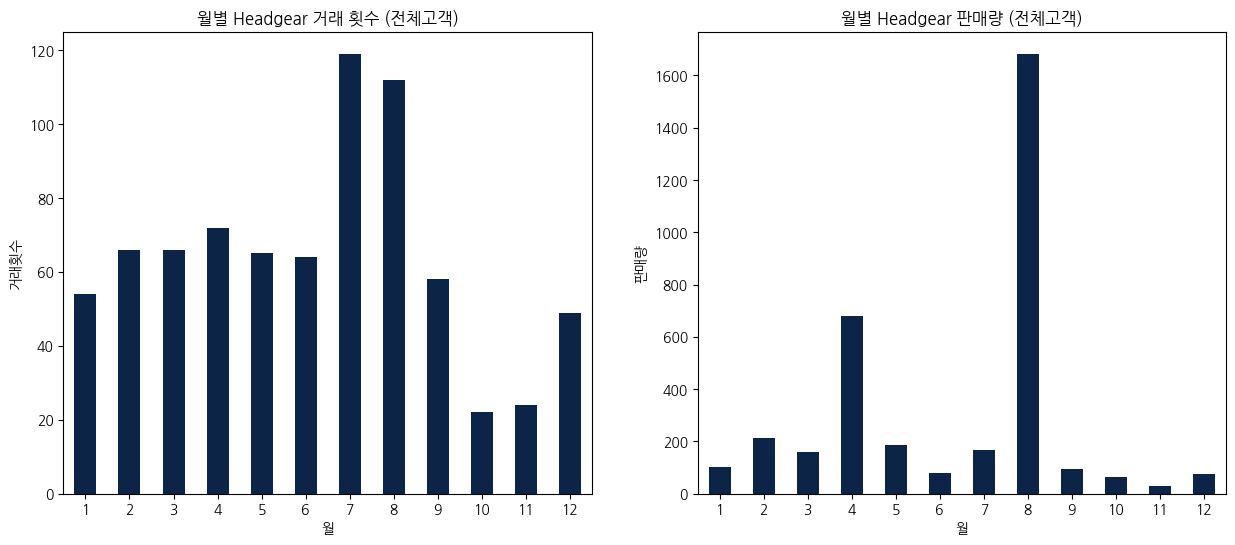

In [ ]:
df['거래날짜']=pd.to_datetime(df['거래날짜'])
monthly_sales_headgear = df[df['제품카테고리'] == 'Headgear']['거래날짜'].dt.month.value_counts().sort_index()
monthly_sales_all = df[df['제품카테고리'] == 'Headgear'].groupby(df['거래날짜'].dt.month)['수량'].sum().sort_index()

plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
monthly_sales_headgear.plot(kind='bar', color='#0B2447')
plt.title('월별 Headgear 거래 횟수 (전체고객)')
plt.xlabel('월')
plt.ylabel('거래횟수')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
monthly_sales_all.plot(kind='bar', color='#0B2447')
plt.title('월별 Headgear 판매량 (전체고객)')
plt.xlabel('월')
plt.ylabel('판매량')
plt.xticks(rotation=0)

특히 4월과 8월에는 대량구매를 한 고객이 있을 것 같아 확인해보았다.

In [ ]:
months_to_check = [4, 8]

for month in months_to_check:
  latent_customers_month_headgear_counts=df[(df['segment']=='잠재충성고객')& (df['거래날짜'].dt.year==2019)& (df['거래날짜'].dt.month == month) & (df['제품카테고리'] == 'Headgear')]['수량'].value_counts()

  print(f"\n{month}월 잠재충성고객의 Headgear 수량:")
  print(latent_customers_month_headgear_counts)


4월 잠재충성고객의 Headgear 수량:
수량
1      10
2       2
500     1
Name: count, dtype: int64

8월 잠재충성고객의 Headgear 수량:
수량
1      29
8       2
4       2
7       1
35      1
29      1
791     1
5       1
10      1
2       1
Name: count, dtype: int64


각각 500, 791개를 구매한 고객이 있었다. 하지만, 시장성을 고려하여 Headgear를 판매하기 위한 전략은 다음과 같다.
* 첫 번째로, 올스타전이 열리는 7월에는 평소보다 20% 할인된 가격으로 야구모자를 판매한다.
* 두 번째로, 8월은 MLB 시즌의 하반기가 시작되므로 30% 할인하여 남은 재고를 최대한 판매하는 전략을 수립한다.

In [ ]:
import folium

# 고객지역의 위도와 경도
locations = {
    'Chicago': (41.8781, -87.6298),
    'California': (35.7783, -119.4179),
    'New York': (40.7128, -74.0060),
    'New Jersey': (40.0583, -74.4057),
    'Washington DC': (38.9072, -77.0369)
}

# 미국 지역의 MLB 야구장의 위도와 경도
ballpark_coordinates = {
    'Wrigley Field': (41.948461, -87.655047),
    'Guaranteed Rate Field': (41.867904, -87.617439),
    'Angel Stadium of Anaheim': (33.800063, -117.880442),
    'Dodger Stadium': (34.073833, -118.240041),
    'Petco Park': (32.707472, -117.157512),
    'Oracle Park': (37.776192, -122.391172),
    'Oakland-Alameda County Coliseum': (37.751092, -122.200472),
    'Yankee Stadium': (40.829644, -73.926194),
    'Citi Field': (40.750569, -73.844914),
    'Prudential Center': (40.738139, -74.174444),
    'Nationals Park': (38.897222, -77.021111)
}

가설: 고객지역 데이터인 5개의 지역에는 다음과 같이 총 11개의 MLB 야구장이 존재한다.
그러므로 Headgear에 대한 수요가 높을 것으로 예상한다.

In [ ]:
map_usa_mlb = folium.Map(location=[37.0902, -95.7129], zoom_start=5)

for city, (lat, lon) in locations.items():
    for ballpark, (ballpark_lat, ballpark_lon) in ballpark_coordinates.items():
        folium.Marker(
            location=(ballpark_lat, ballpark_lon),
            popup=ballpark,
            icon=folium.Icon(color='red'),
        ).add_to(map_usa_mlb)

    radius_multiplier = 3.5 if city == 'California' else 1
    folium.Circle(
        location=(lat, lon),
        radius=120000 * radius_multiplier,
        color='blue',
        fill=True,
        fill_color='cyan',
        fill_opacity=0.6,
    ).add_to(map_usa_mlb)

map_usa_mlb

### 3-5. Apparel(의류) 판매 전략

In [ ]:
apparel_transactions = df[df['제품카테고리'] == 'Apparel']
user_groups = apparel_transactions.groupby('고객ID')

# 사용자별로 첫 구매일
first_purchase_dates = user_groups['거래날짜'].min()

# 사용자별로 재구매까지 걸린 일 수
repeated_purchase_days = []
for user_id, group_data in user_groups:
    first_purchase_date = first_purchase_dates.loc[user_id]
    repurchase_dates = group_data['거래날짜'][group_data['거래날짜'] > first_purchase_date]
    if repurchase_dates.empty:
        repeated_purchase_days.append(0)
    else:
        repeated_purchase_days.append((repurchase_dates.min() - first_purchase_date).days)

repeated_purchase_days_filtered = [days for days in repeated_purchase_days if days > 0]

repeated_purchase_count = sum(1 for days in repeated_purchase_days if days > 0)
total_user_count = len(first_purchase_dates)
repurchase_rate = repeated_purchase_count / total_user_count

print(f"전체 사용자 수: {df['고객ID'].nunique()}")
print(f"apparel을 구매한 전체 사용자 수: {total_user_count}")
print(f"재구매한 사용자 수: {repeated_purchase_count}")
print(f"재구매율: {repurchase_rate:.2%}")

전체 사용자 수: 1468
apparel을 구매한 전체 사용자 수: 1323
재구매한 사용자 수: 584
재구매율: 44.14%


In [ ]:
from collections import Counter

repeated_purchase_count = Counter(repeated_purchase_days)
print("재구매 일수별 개수:")
for days,count in sorted(repeated_purchase_count.items()):
  print(f"{days}일:{count}개")

재구매 일수별 개수:
0일:739개
1일:153개
2일:2개
3일:3개
4일:3개
5일:1개
6일:3개
7일:2개
8일:1개
9일:3개
10일:2개
11일:4개
12일:1개
13일:2개
14일:3개
15일:6개
16일:3개
17일:2개
18일:1개
19일:3개
20일:3개
21일:1개
22일:3개
23일:1개
24일:4개
25일:2개
26일:1개
27일:1개
28일:6개
29일:1개
30일:3개
31일:2개
32일:1개
33일:3개
34일:1개
35일:4개
36일:6개
37일:2개
38일:1개
39일:2개
40일:1개
41일:1개
42일:2개
43일:1개
44일:2개
45일:3개
46일:2개
47일:3개
48일:1개
49일:1개
50일:6개
51일:2개
52일:1개
53일:1개
54일:2개
55일:4개
56일:7개
58일:4개
59일:3개
60일:1개
61일:2개
62일:2개
63일:3개
64일:1개
65일:4개
66일:3개
67일:2개
68일:5개
70일:6개
71일:2개
72일:2개
73일:3개
74일:5개
75일:4개
76일:3개
78일:1개
79일:5개
81일:2개
82일:5개
83일:3개
84일:1개
85일:3개
86일:1개
87일:4개
88일:4개
90일:5개
91일:2개
92일:2개
93일:1개
94일:3개
95일:2개
96일:2개
97일:1개
98일:6개
100일:2개
101일:2개
102일:1개
103일:1개
104일:1개
106일:3개
108일:1개
109일:3개
110일:3개
111일:3개
112일:1개
113일:3개
114일:3개
116일:3개
117일:2개
118일:1개
119일:1개
120일:1개
121일:2개
123일:2개
124일:1개
125일:1개
126일:3개
127일:1개
129일:1개
130일:2개
131일:4개
132일:1개
133일:1개
134일:3개
135일:1개
136일:1개
137일:1개
138일:1개
139일:4개
140일:3개
141일:3개
142일:5개
143일:3개
144일:1개
145일:3개
146일:1개


바로 다음날 재구매를 하거나 거의 안함

In [ ]:
# 첫 재구매일이 1일인 사용자
first_repurchase_1_day = [(user_id, repurchase_date) for user_id, repurchase_date in zip(user_groups.groups.keys(), repeated_purchase_days) if repurchase_date == 1]

# 첫 재구매일이 1일인 사용자들에 대한 첫 재구매일과 다음 재구매일 사이의 일수
days_to_next_repurchase_list = []

for user_id, repurchase_date in first_repurchase_1_day:
    first_purchase_date = first_purchase_dates.loc[user_id]
    next_purchase_date = apparel_transactions[(apparel_transactions['고객ID'] == user_id) & (apparel_transactions['거래날짜'] > first_purchase_date)]['거래날짜'].min()
    if next_purchase_date:
        second_purchase_date = apparel_transactions[(apparel_transactions['고객ID'] == user_id) & (apparel_transactions['거래날짜'] > next_purchase_date)]['거래날짜'].min()
        if second_purchase_date:
            days_to_next_repurchase = (second_purchase_date - next_purchase_date).days
            days_to_next_repurchase_list.append(days_to_next_repurchase)

# 첫번째 재구매일이 바로 다음날인 사용자들의 고객 ID
users_with_immediate_2nd_purchase = [user_id for user_id, repurchase_date in first_repurchase_1_day if repurchase_date == 1]
df_immediate_2nd_purchase = apparel_transactions[apparel_transactions['고객ID'].isin(users_with_immediate_2nd_purchase)]

# 각 사용자별 첫 번째와 두 번째 재구매 사이의 일 수
days_to_next_purchase_list = []

for user_id in users_with_immediate_2nd_purchase:
    first_purchase_date = first_purchase_dates.loc[user_id]
    next_purchase_date = apparel_transactions[(apparel_transactions['고객ID'] == user_id) & (apparel_transactions['거래날짜'] > first_purchase_date)]['거래날짜'].min()
    if next_purchase_date:
        second_purchase_date = apparel_transactions[(apparel_transactions['고객ID'] == user_id) & (apparel_transactions['거래날짜'] > next_purchase_date)]['거래날짜'].min()
        if second_purchase_date:
            days_to_next_purchase = (second_purchase_date - next_purchase_date).days
            days_to_next_purchase_list.append(days_to_next_purchase)

non_nan_count = np.count_nonzero(~np.isnan(days_to_next_purchase_list))
total_count = len(days_to_next_purchase_list)
non_nan_percentage = non_nan_count / total_count * 100

print(f"재구매 고객의 다음 재구매할 확률: {non_nan_percentage:.2f}%")

재구매 고객의 다음 재구매할 확률: 41.18%


Apparel(의류)의 재구매율은 44%이다. 재구매 사용자 584명 중 153명이 바로 다음날 재구매했는데, 이 153명이 또 재구매 할 확률은 41.18%이다.

=> 의류를 처음 구매하고, 바로 다음날 구매할 수 있도록 유도한다면 전체적인 재구매율이 올라갈 것이다.
이를 위해 구매한 상품과 매치되는 옷을 다음날 알림을 통해 전송하거나, 연속 출석 혜택을 주는 방법을 제안한다